# Enhanced Tax Loss Harvesting (TLH) Analysis

**Analysis Period**: 2014–2024 (11 years, Russell 1000 universe)

---

### Three Portfolio Strategies

| # | Strategy | Description |
|---|----------|-------------|
| 1 | **Random** | Baseline — completely random stock selection |
| 2 | **Target Alpha** | Portfolios calibrated to specific pre-tax alphas (−2 % → +4 %) |
| 3 | **Momentum** | Long high-momentum, short low-momentum (exponential-decay signal) |

### Monthly TLH Mechanism
At every month-end each position is evaluated:
- **Losers (P&L < 0)** → liquidate, realise the loss, buy a replacement at the same dollar amount  
- **Winners (P&L > 0)** → hold, unrealised gain accumulates  

### Post-Tax Alpha Formula
```
Post-Tax Alpha = Pre-Tax Alpha
    + (Realised Losses × Tax Rate) / Capital      ← TLH benefit
    − (Unrealised Gains × Tax Rate) / Capital     ← deferred liability
    − Borrowing Cost %                            ← leverage cost
```

### Notebook Structure
1. **Setup** — configuration, data loading
2. **Core Engine** — monthly TLH simulation
3. **Portfolio Generators** — random, target-alpha, momentum
4. **Run Simulations** — all strategies × leverage × borrow rates
5. **Strategy Results** — per-strategy tables
6. **Comparative Analysis** — cross-strategy visuals & decomposition
7. **Sector Deep-Dive** — which sectors drive TLH?

---
# Part 1 — Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.4f}'.format)

# Professional colour palette (colourblind-friendly)
COLORS = {
    'blue':   '#2166AC',
    'red':    '#B2182B',
    'green':  '#1B7837',
    'orange': '#E66101',
    'purple': '#762A83',
    'gray':   '#878787',
    'teal':   '#01796F',
}
STRATEGY_COLORS = {'Random': COLORS['blue'], 'Target Alpha': COLORS['orange'], 'Momentum': COLORS['green']}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

print('Libraries loaded.')

Libraries loaded.


In [4]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CAPITAL          = 10_000_000   # $10 M
TAX_RATE         = 0.25         # 25 %
BASE_N_LONG      = 50           # scales with leverage

TARGET_ALPHAS    = [-0.02, -0.01, 0.00, 0.01, 0.02, 0.03, 0.04]

LEVERAGE_LEVELS  = [
    (1.00, 0.00),   # 100/0
    (1.30, 0.30),   # 130/30
    (1.50, 0.50),   # 150/50
    (2.00, 1.00),   # 200/100
]

BORROWING_RATES  = [0.00, 0.03, 0.05, 0.07]

N_RANDOM_PORTFOLIOS   = 20
N_TARGET_PORTFOLIOS   = 5
N_MOMENTUM_PORTFOLIOS = 10
SEED_BASE             = 42

START_YEAR = 2014
END_YEAR   = 2024

MOMENTUM_LOOKBACK_DAYS = 60
MOMENTUM_DECAY_FACTOR  = 0.95

def get_position_counts(long_gross, short_gross):
    """Position counts scale linearly with leverage."""
    n_long  = int(BASE_N_LONG * long_gross)
    n_short = int(BASE_N_LONG * short_gross) if short_gross > 0 else 0
    return n_long, n_short

print('Configuration')
print(f'  Capital       : ${CAPITAL:,.0f}')
print(f'  Tax Rate      : {TAX_RATE:.0%}')
print(f'  Leverage      : {[f"{int(l*100)}/{int(s*100)}" for l,s in LEVERAGE_LEVELS]}')
print(f'  Borrow Rates  : {[f"{r:.0%}" for r in BORROWING_RATES]}')
print(f'  Target Alphas : {[f"{a:+.0%}" for a in TARGET_ALPHAS]}')
print()
print('Positions by leverage:')
for lg, sg in LEVERAGE_LEVELS:
    nl, ns = get_position_counts(lg, sg)
    print(f'  {int(lg*100)}/{int(sg*100)}: {nl} longs, {ns} shorts')

Configuration
  Capital       : $10,000,000
  Tax Rate      : 25%
  Leverage      : ['100/0', '130/30', '150/50', '200/100']
  Borrow Rates  : ['0%', '3%', '5%', '7%']
  Target Alphas : ['-2%', '-1%', '+0%', '+1%', '+2%', '+3%', '+4%']

Positions by leverage:
  100/0: 50 longs, 0 shorts
  130/30: 65 longs, 15 shorts
  150/50: 75 longs, 25 shorts
  200/100: 100 longs, 50 shorts


In [5]:
# =============================================================================
# LOAD DATA
# =============================================================================

FILE_PATHS = {
    2014: 'r1000_2013-07-01_2014-06-30.csv',
    2015: 'r1000_2014-07-01_2015-06-30.csv',
    2016: 'r1000_2015-07-01_2016-06-30.csv',
    2017: 'r1000_2016-07-01_2017-06-30.csv',
    2018: 'r1000_2017-07-03_2018-06-29.csv',
    2019: 'r1000_2018-07-02_2019-06-28.csv',
    2020: 'r1000_2019-07-01_2020-06-30.csv',
    2021: 'r1000_2020-07-01_2021-06-30.csv',
    2022: 'r1000_2021-07-01_2022-06-30.csv',
    2023: 'r1000_2022-07-01_2023-06-30.csv',
    2024: 'r1000_2023-07-03_2024-06-28.csv',
}

dfs = {}
print('Loading daily returns …')
for year, path in FILE_PATHS.items():
    try:
        df = pd.read_csv(path, parse_dates=['date'], na_values=['', ' '])
        df['ret_adj'] = pd.to_numeric(df['ret_adj'], errors='coerce')
        dfs[year] = df
        print(f'  {year}: {len(df):>8,} rows, {df["ticker"].nunique():>4} tickers')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND')
print(f'Loaded {len(dfs)} years.')

# Sector mapping
try:
    _sdf = pd.read_csv('us_sector_mapping.csv')
    TICKER_TO_SECTOR = dict(zip(_sdf['ticker'], _sdf['sector']))
    print(f'Sector mapping: {len(TICKER_TO_SECTOR):,} tickers')
except FileNotFoundError:
    TICKER_TO_SECTOR = {}
    print('Sector mapping not found — sector analysis will be skipped')

for year in dfs:
    dfs[year]['sector'] = dfs[year]['ticker'].map(TICKER_TO_SECTOR)

Loading daily returns …
  2014:  200,465 rows,  798 tickers
  2015:  198,678 rows,  798 tickers
  2016:  197,651 rows,  797 tickers
  2017:  199,566 rows,  798 tickers
  2018:  198,417 rows,  797 tickers
  2019:  195,987 rows,  798 tickers
  2020:  199,319 rows,  798 tickers
  2021:  199,959 rows,  798 tickers
  2022:  199,197 rows,  797 tickers
  2023:  198,543 rows,  797 tickers
  2024:  198,572 rows,  797 tickers
Loaded 11 years.
Sector mapping: 22,485 tickers


In [6]:
# =============================================================================
# PRE-COMPUTE: Market returns, monthly return matrices
# =============================================================================

def compute_market_return(df, col='ret_adj'):
    return float((1 + df.groupby('date')[col].mean().dropna()).prod() - 1)

MARKET_RETURNS = {y: compute_market_return(df) for y, df in dfs.items()}

print('Market Returns:')
for y, r in MARKET_RETURNS.items():
    print(f'  {y}: {r:+.2%}')

# Monthly return matrices (month_end × ticker)
def build_monthly_matrix(df, col='ret_adj'):
    d = df[['ticker', 'date', col]].copy()
    d['date'] = pd.to_datetime(d['date'])
    d['ym'] = d['date'].dt.to_period('M')
    d['_l1p'] = np.log1p(d[col].astype(float))
    monthly = d.groupby(['ticker', 'ym'], sort=False)['_l1p'].sum().pipe(np.expm1).reset_index(name='mret')
    monthly['me'] = monthly['ym'].dt.to_timestamp('M')
    return monthly.pivot(index='me', columns='ticker', values='mret').sort_index().fillna(0.0)

print('\nBuilding monthly matrices …')
MONTHLY_MAT  = {}
ALL_TICKERS  = {}
for year, df in dfs.items():
    MONTHLY_MAT[year] = build_monthly_matrix(df)
    ALL_TICKERS[year] = df['ticker'].dropna().unique()
    print(f'  {year}: {MONTHLY_MAT[year].shape[0]} months × {MONTHLY_MAT[year].shape[1]} tickers')
print('Done.')

Market Returns:
  2014: +30.99%
  2015: +7.42%
  2016: +4.41%
  2017: +22.06%
  2018: +17.42%
  2019: +12.17%
  2020: +7.34%
  2021: +55.60%
  2022: -12.97%
  2023: +20.29%
  2024: +19.08%

Building monthly matrices …
  2014: 12 months × 798 tickers
  2015: 12 months × 798 tickers
  2016: 12 months × 797 tickers
  2017: 12 months × 798 tickers
  2018: 12 months × 797 tickers
  2019: 12 months × 798 tickers
  2020: 12 months × 798 tickers
  2021: 12 months × 798 tickers
  2022: 12 months × 797 tickers
  2023: 12 months × 797 tickers
  2024: 12 months × 797 tickers
Done.


---
# Part 2 — Core Monthly TLH Engine

At each month-end:
1. Update all position values using that month's return
2. **Losers** → realise loss, replace ticker, reset cost basis
3. **Winners** → hold, keep original cost basis
4. Rebalance short notional to maintain target leverage ratio

**Fix vs. prior version**: short positions now track `value` properly  
(compounds with stock return so unrealised gains/losses are symmetric  
between longs and shorts).

In [7]:
# =============================================================================
# CORE: MONTHLY TLH SIMULATION (GENERIC - for Random & Target Alpha)  (vectorised, fixed short tracking)
# =============================================================================

def simulate_monthly_tlh(
    df, monthly_ret, initial_longs, initial_shorts,
    long_gross, short_gross, capital, rng,
    replacement_mode='random', target_alpha=None, market_return=None,
    monthly_mat=None, all_tickers=None,
):
    """
    Simulate one year of monthly TLH rebalancing.

    Returns dict:
        total_return, realized_losses, unrealized_gains,
        n_harvests, harvest_by_sector, monthly_returns, monthly_tlh,
        final_positions, leverage_tracking
    """
    if monthly_mat is None:
        raise ValueError('Pass monthly_mat')
    if all_tickers is None:
        all_tickers = df['ticker'].dropna().unique()

    n_long  = len(initial_longs)
    n_short = len(initial_shorts) if short_gross > 0 else 0

    tickers    = np.array(list(initial_longs) + list(initial_shorts[:n_short]), dtype=object)
    sides      = np.array(['long']*n_long + ['short']*n_short, dtype=object)

    if tickers.size == 0:
        return {k: (0.0 if k != 'harvest_by_sector' else {}) for k in
                ['total_return','realized_losses','unrealized_gains','n_harvests',
                 'harvest_by_sector','monthly_returns','monthly_tlh','final_positions','leverage_tracking']}

    long_notional  = (capital * long_gross  / n_long)  if n_long  > 0 else 0.0
    short_notional = (capital * short_gross / n_short) if n_short > 0 else 0.0

    cost_basis = np.where(sides == 'long', long_notional, short_notional).astype(float)
    value      = cost_basis.copy()
    current_set = set(tickers.tolist())

    # tracking
    realized_losses    = 0.0
    n_harvests         = 0
    harvest_by_sector  = {}
    monthly_returns    = []
    monthly_tlh        = []
    leverage_tracking  = []

    months  = monthly_mat.index.to_numpy()
    is_long = (sides == 'long')
    is_short = ~is_long

    def draw_replacements(k):
        reps = []
        while len(reps) < k:
            c = rng.choice(all_tickers)
            if c not in current_set and c not in reps:
                reps.append(c)
        return np.array(reps, dtype=object)

    for m in months:
        r = monthly_mat.loc[m].reindex(tickers).to_numpy(dtype=float)
        r = np.nan_to_num(r, nan=0.0)

        # ---- portfolio P&L this month ----
        pnl_long  = value[is_long] * r[is_long]           # longs gain when stock rises
        pnl_short = -value[is_short] * r[is_short]        # shorts gain when stock falls
        month_pnl = float(pnl_long.sum() + pnl_short.sum())
        monthly_returns.append(month_pnl / capital)

        # ---- update values ----
        # FIX: both longs AND shorts compound with market
        # Long value rises when stock rises
        value[is_long]  *= (1.0 + r[is_long])
        # Short liability rises when stock rises (bad), falls when stock falls (good)
        # Think of 'value' as the cost to close the short
        value[is_short] *= (1.0 + r[is_short])

        # ---- identify losers ----
        # Long loser:  value < cost_basis (stock fell below purchase)
        # Short loser: value > cost_basis (stock rose above where we shorted)
        position_pnl = np.zeros_like(cost_basis)
        position_pnl[is_long]  = value[is_long]  - cost_basis[is_long]   # +if stock up
        position_pnl[is_short] = cost_basis[is_short] - value[is_short]  # +if stock down

        losers = position_pnl < 0

        # ---- harvest losers ----
        month_harvest = 0.0
        if losers.any():
            loss_amounts = np.abs(position_pnl[losers])
            total_loss   = float(loss_amounts.sum())
            realized_losses += total_loss
            month_harvest    = total_loss
            n_harvests      += int(losers.sum())

            for t, la in zip(tickers[losers], loss_amounts):
                sec = TICKER_TO_SECTOR.get(t, 'Unknown')
                harvest_by_sector[sec] = harvest_by_sector.get(sec, 0.0) + float(la)

            k = int(losers.sum())
            new_tickers = draw_replacements(k)
            for old in tickers[losers]: current_set.discard(old)
            for nt  in new_tickers:     current_set.add(nt)
            tickers[losers] = new_tickers

            # Reset basis to current value (new purchase / new short entry)
            cost_basis[losers] = value[losers]

        monthly_tlh.append(month_harvest)

        # ---- dynamic leverage rebalancing ----
        cur_long_val  = float(value[is_long].sum())
        cur_short_val = float(value[is_short].sum()) if n_short > 0 else 0.0
        if short_gross > 0 and n_short > 0 and long_gross > 0:
            implied_cap     = cur_long_val / long_gross
            target_short    = implied_cap * short_gross
            drift           = abs(cur_short_val - target_short)
            if drift > capital * 0.01:
                sf = target_short / cur_short_val if cur_short_val > 0 else 1.0
                value[is_short]      *= sf
                cost_basis[is_short] *= sf

        leverage_tracking.append((cur_long_val, cur_short_val))

    # ---- year-end unrealised gains ----
    position_pnl_final = np.zeros_like(cost_basis)
    position_pnl_final[is_long]  = value[is_long]  - cost_basis[is_long]
    position_pnl_final[is_short] = cost_basis[is_short] - value[is_short]
    unrealized_gains = float(np.maximum(position_pnl_final, 0.0).sum())

    total_return = float((1.0 + pd.Series(monthly_returns)).prod() - 1.0)

    final_positions = [
        {'ticker': t, 'side': s, 'cost_basis': float(cb), 'current_value': float(v)}
        for t, s, cb, v in zip(tickers, sides, cost_basis, value)
    ]

    return {
        'total_return':      total_return,
        'realized_losses':   float(realized_losses),
        'unrealized_gains':  unrealized_gains,
        'n_harvests':        int(n_harvests),
        'harvest_by_sector': harvest_by_sector,
        'monthly_returns':   monthly_returns,
        'monthly_tlh':       monthly_tlh,
        'final_positions':   final_positions,
        'leverage_tracking': leverage_tracking,
    }

print('Core TLH engine loaded (fixed short P&L tracking).')

Core TLH engine loaded (fixed short P&L tracking).


In [8]:
# =============================================================================
# MOMENTUM-SPECIFIC TLH SIMULATION (Signal-Based Harvesting)
# =============================================================================
#
# This is a DIFFERENT strategy from the generic TLH simulation:
# - Longs are closed when they LOSE positive momentum (signal turns weak/negative)
# - Shorts are closed when they LOSE negative momentum (signal turns strong/positive)
# - Harvesting is based on SIGNAL CHANGE, not just price P&L
# - But we still only harvest if there's a LOSS to realize (for tax benefit)
#
# Monthly process:
# 1. Recalculate momentum for all held positions
# 2. Identify longs that lost momentum OR shorts that gained momentum
# 3. Among those, harvest the ones with actual losses
# 4. Replace with new high/low momentum stocks

def simulate_momentum_tlh(
    df,                    # Current year's daily data
    initial_longs,         # Initial long tickers
    initial_shorts,        # Initial short tickers  
    long_gross,            # Target long exposure
    short_gross,           # Target short exposure
    capital,               # Initial capital
    rng,                   # Random number generator
    monthly_mat,           # Month-end return matrix
    all_tickers,           # All available tickers
    lookback_days=60,      # Momentum lookback
    decay_factor=0.95,     # Momentum decay
    momentum_threshold=0.0, # Signal threshold (0 = must be positive for longs)
):
    """
    Momentum-based TLH: harvest when positions lose their momentum signal.
    
    Strategy Logic:
    - LONG positions: Should have POSITIVE momentum. Close if momentum turns negative.
    - SHORT positions: Should have NEGATIVE momentum. Close if momentum turns positive.
    - Only harvest if there's an actual LOSS (for tax benefit).
    - Replace harvested positions with new stocks that have the right signal.
    """
    
    n_long  = len(initial_longs)
    n_short = len(initial_shorts) if short_gross > 0 else 0
    
    if n_long + n_short == 0:
        return {
            'total_return': 0.0, 'realized_losses': 0.0, 'unrealized_gains': 0.0,
            'n_harvests': 0, 'harvest_by_sector': {}, 'monthly_returns': [],
            'monthly_tlh': [], 'final_positions': [], 'leverage_tracking': [],
            'signal_harvests': 0, 'pnl_harvests': 0,
        }
    
    # Initialize position arrays
    tickers    = np.array(list(initial_longs) + list(initial_shorts[:n_short]), dtype=object)
    sides      = np.array(['long']*n_long + ['short']*n_short, dtype=object)
    
    long_notional  = (capital * long_gross / n_long) if n_long > 0 else 0.0
    short_notional = (capital * short_gross / n_short) if n_short > 0 else 0.0
    
    cost_basis = np.where(sides == 'long', long_notional, short_notional).astype(float)
    value      = cost_basis.copy()
    current_set = set(tickers.tolist())
    
    # Tracking
    realized_losses   = 0.0
    n_harvests        = 0
    signal_harvests   = 0  # Harvests due to signal loss
    pnl_harvests      = 0  # Harvests due to P&L loss (no signal change)
    harvest_by_sector = {}
    monthly_returns   = []
    monthly_tlh       = []
    leverage_tracking = []
    
    months = monthly_mat.index.to_numpy()
    is_long = (sides == 'long')
    is_short = ~is_long
    
    # Get daily data for momentum calculation
    daily_data = df[['ticker', 'date', 'ret_adj']].copy()
    daily_data['date'] = pd.to_datetime(daily_data['date'])
    
    def get_momentum_at_date(ref_date):
        """Calculate momentum for all tickers as of ref_date."""
        d = daily_data[daily_data['date'] <= ref_date].sort_values(
            ['ticker', 'date'], ascending=[True, False])
        d = d.groupby('ticker', group_keys=False).head(lookback_days)
        
        w = np.array([decay_factor**i for i in range(lookback_days)])
        
        def _wm(g):
            n = len(g)
            if n == 0: return 0.0
            ww = w[:n].copy()
            ww = ww / ww.sum()
            return float(np.sum(g['ret_adj'].values * ww))
        
        scores = d.groupby('ticker').apply(_wm)
        return scores
    
    def find_momentum_stocks(momentum_scores, n_needed, direction, exclude):
        """Find stocks with desired momentum direction, excluding current holdings."""
        available = momentum_scores[~momentum_scores.index.isin(exclude)]
        if direction == 'high':
            candidates = available.nlargest(n_needed * 3)
            candidates = candidates[candidates > momentum_threshold]
        else:  # low
            candidates = available.nsmallest(n_needed * 3)
            candidates = candidates[candidates < -momentum_threshold]
        
        if len(candidates) >= n_needed:
            return list(rng.choice(candidates.index.tolist(), size=n_needed, replace=False))
        elif len(candidates) > 0:
            return candidates.index.tolist()
        else:
            # Fallback: just pick from available
            return list(rng.choice(available.index.tolist(), 
                                   size=min(n_needed, len(available)), replace=False))
    
    for month_idx, m in enumerate(months):
        # Get daily date closest to month-end for momentum calculation
        month_dates = daily_data[daily_data['date'].dt.to_period('M') == pd.Period(m, 'M')]['date']
        if len(month_dates) > 0:
            ref_date = month_dates.max()
        else:
            ref_date = m
        
        # Get this month's returns
        r = monthly_mat.loc[m].reindex(tickers).to_numpy(dtype=float)
        r = np.nan_to_num(r, nan=0.0)
        
        # Update position values
        pnl_long  = value[is_long] * r[is_long]
        pnl_short = -value[is_short] * r[is_short]
        month_pnl = float(pnl_long.sum() + pnl_short.sum())
        monthly_returns.append(month_pnl / capital)
        
        value[is_long]  *= (1.0 + r[is_long])
        value[is_short] *= (1.0 + r[is_short])
        
        # Calculate position P&L
        position_pnl = np.zeros_like(cost_basis)
        position_pnl[is_long]  = value[is_long] - cost_basis[is_long]
        position_pnl[is_short] = cost_basis[is_short] - value[is_short]
        
        # Calculate current momentum for all held positions
        momentum_scores = get_momentum_at_date(ref_date)
        held_momentum = np.array([momentum_scores.get(t, 0.0) for t in tickers])
        
        # ====================================================================
        # IDENTIFY POSITIONS TO HARVEST (Signal-Based Logic)
        # ====================================================================
        
        # Longs that lost positive momentum (signal turned negative/weak)
        long_lost_signal = is_long & (held_momentum < momentum_threshold)
        
        # Shorts that lost negative momentum (signal turned positive/strong)  
        short_lost_signal = is_short & (held_momentum > -momentum_threshold)
        
        # Combined: positions that lost their signal
        lost_signal = long_lost_signal | short_lost_signal
        
        # But we only HARVEST if there's an actual loss (for tax benefit)
        has_loss = position_pnl < 0
        
        # Harvest = lost signal AND has loss
        to_harvest = lost_signal & has_loss
        
        # Also harvest any position with significant loss even if signal intact
        # (standard TLH behavior for deep losses)
        deep_loss = position_pnl < -0.10 * cost_basis  # >10% loss
        to_harvest = to_harvest | (has_loss & deep_loss)
        
        # Track harvest reasons
        signal_harvests += int((lost_signal & has_loss).sum())
        pnl_harvests    += int((~lost_signal & has_loss & deep_loss).sum())
        
        # ====================================================================
        # EXECUTE HARVESTS
        # ====================================================================
        month_harvest = 0.0
        
        if to_harvest.any():
            loss_amounts = np.abs(position_pnl[to_harvest])
            total_loss   = float(loss_amounts.sum())
            realized_losses += total_loss
            month_harvest    = total_loss
            n_harvests      += int(to_harvest.sum())
            
            # Sector attribution
            for t, la in zip(tickers[to_harvest], loss_amounts):
                sec = TICKER_TO_SECTOR.get(t, 'Unknown')
                harvest_by_sector[sec] = harvest_by_sector.get(sec, 0.0) + float(la)
            
            # Find replacements with correct momentum
            n_long_harvest  = int((to_harvest & is_long).sum())
            n_short_harvest = int((to_harvest & is_short).sum())
            
            # Remove old tickers from current set
            for old in tickers[to_harvest]:
                current_set.discard(old)
            
            # Find new high-momentum stocks for long replacements
            new_longs = []
            if n_long_harvest > 0:
                new_longs = find_momentum_stocks(momentum_scores, n_long_harvest, 'high', current_set)
            
            # Find new low-momentum stocks for short replacements
            new_shorts = []
            if n_short_harvest > 0:
                new_shorts = find_momentum_stocks(momentum_scores, n_short_harvest, 'low', 
                                                  current_set | set(new_longs))
            
            # Replace tickers
            new_tickers = new_longs + new_shorts
            harvest_indices = np.where(to_harvest)[0]
            
            for i, new_t in zip(harvest_indices, new_tickers):
                tickers[i] = new_t
                current_set.add(new_t)
                cost_basis[i] = value[i]  # Reset basis
        
        monthly_tlh.append(month_harvest)
        
        # Track leverage
        cur_long_val  = float(value[is_long].sum())
        cur_short_val = float(value[is_short].sum()) if n_short > 0 else 0.0
        leverage_tracking.append((cur_long_val, cur_short_val))
    
    # Year-end unrealized gains
    position_pnl_final = np.zeros_like(cost_basis)
    position_pnl_final[is_long]  = value[is_long] - cost_basis[is_long]
    position_pnl_final[is_short] = cost_basis[is_short] - value[is_short]
    unrealized_gains = float(np.maximum(position_pnl_final, 0.0).sum())
    
    total_return = float((1.0 + pd.Series(monthly_returns)).prod() - 1.0)
    
    final_positions = [
        {'ticker': t, 'side': s, 'cost_basis': float(cb), 'current_value': float(v)}
        for t, s, cb, v in zip(tickers, sides, cost_basis, value)
    ]
    
    return {
        'total_return':      total_return,
        'realized_losses':   float(realized_losses),
        'unrealized_gains':  unrealized_gains,
        'n_harvests':        int(n_harvests),
        'signal_harvests':   int(signal_harvests),
        'pnl_harvests':      int(pnl_harvests),
        'harvest_by_sector': harvest_by_sector,
        'monthly_returns':   monthly_returns,
        'monthly_tlh':       monthly_tlh,
        'final_positions':   final_positions,
        'leverage_tracking': leverage_tracking,
    }

print('Momentum-specific TLH simulation loaded.')
print('  - Harvests when: long loses positive momentum OR short loses negative momentum')
print('  - Only harvests if position has actual loss (for tax benefit)')
print('  - Replaces with new stocks that have the correct momentum signal')


Momentum-specific TLH simulation loaded.
  - Harvests when: long loses positive momentum OR short loses negative momentum
  - Only harvests if position has actual loss (for tax benefit)
  - Replaces with new stocks that have the correct momentum signal


---
# Part 3 — Portfolio Generators

In [9]:
# =============================================================================
# RANDOM PORTFOLIO
# =============================================================================

def make_random_portfolio(df, n_long, n_short, seed):
    rng = np.random.default_rng(seed)
    t   = df['ticker'].dropna().unique()
    n   = min(n_long + n_short, len(t))
    sel = rng.choice(t, size=n, replace=False)
    return sel[:n_long].tolist(), sel[n_long:n_long+n_short].tolist() if n_short else []

# =============================================================================
# TARGET-ALPHA PORTFOLIO
# =============================================================================

def find_target_alpha_portfolio(df, target_alpha, market_return,
                                n_long, n_short, long_gross, short_gross,
                                seed, n_attempts=500):
    rng = np.random.default_rng(seed)
    all_t = df['ticker'].dropna().unique()
    ann   = ((1.0 + df['ret_adj']).groupby(df['ticker']).prod(min_count=1) - 1.0).to_dict()

    best, best_diff, best_alpha = None, float('inf'), None
    for _ in range(n_attempts):
        nt = min(n_long + n_short, len(all_t))
        sel = rng.choice(all_t, size=nt, replace=False)
        l, s = sel[:n_long], sel[n_long:]
        lr = np.mean([ann.get(t, 0.) for t in l]) * long_gross
        sr = -np.mean([ann.get(t, 0.) for t in s]) * short_gross if short_gross > 0 and len(s) else 0.
        a  = (lr + sr) - market_return
        d  = abs(a - target_alpha)
        if d < best_diff:
            best, best_diff, best_alpha = (l.tolist(), s.tolist()), d, a
    return best[0], best[1], best_alpha

# =============================================================================
# MOMENTUM PORTFOLIO (FIXED - NO LOOKAHEAD BIAS)
# =============================================================================
# 
# FIX: Momentum is now calculated using the LAST N days of the PREVIOUS year's
# data, not the first N days of the current year. This eliminates lookahead bias.
#
# The simulation runner passes `df_prior` (previous year) for momentum calculation
# and `df` (current year) for the list of tradeable tickers.

def calculate_momentum_vectorized(df, reference_date, lookback_days, decay_factor):
    """Calculate momentum signals using data UP TO reference_date (inclusive)."""
    d = df[df['date'] <= reference_date].sort_values(['ticker','date'], ascending=[True,False])
    if len(d) == 0:
        return pd.Series(0.0, index=df['ticker'].dropna().unique())
    d = d.groupby('ticker', group_keys=False).head(lookback_days)
    w = np.array([decay_factor**i for i in range(lookback_days)])
    def _wm(g):
        n = len(g)
        ww = w[:n]; ww = ww / ww.sum()
        return float(np.sum(g['ret_adj'].values * ww))
    scores = d.groupby('ticker').apply(_wm)
    return scores.reindex(df['ticker'].dropna().unique(), fill_value=0.0)

def make_momentum_portfolio(df_current, df_prior, n_long, n_short, seed,
                            lookback_days=60, decay_factor=0.95):
    """
    Create momentum portfolio using PRIOR YEAR data (no lookahead bias).
    
    Args:
        df_current: Current year's data (for tradeable ticker universe)
        df_prior:   Previous year's data (for momentum calculation)
        n_long, n_short: Position counts
        seed: Random seed
        lookback_days: Days of prior returns to use
        decay_factor: Exponential decay weight
    
    Returns:
        (longs, shorts) lists
    """
    rng = np.random.default_rng(seed)
    
    # Get tradeable universe from current year
    current_tickers = set(df_current['ticker'].dropna().unique())
    
    if df_prior is None or len(df_prior) == 0:
        # First year: fall back to random selection (no prior data)
        return make_random_portfolio(df_current, n_long, n_short, seed)
    
    # Calculate momentum using LAST date of prior year
    prior_dates = sorted(df_prior['date'].dropna().unique())
    ref_date = prior_dates[-1]  # Last day of prior year
    
    scores = calculate_momentum_vectorized(df_prior, ref_date, lookback_days, decay_factor)
    
    # Filter to only tickers that exist in BOTH years
    scores = scores[scores.index.isin(current_tickers)]
    
    if len(scores) < n_long + n_short:
        return make_random_portfolio(df_current, n_long, n_short, seed)
    
    ranked = scores.sort_values(ascending=False)
    top    = ranked.head(max(n_long * 2, 20)).index.tolist()
    bottom = ranked.tail(max(n_short * 2, 10)).index.tolist() if n_short > 0 else []
    
    longs  = list(rng.choice(top,    size=min(n_long, len(top)),    replace=False))
    shorts = list(rng.choice(bottom, size=min(n_short, len(bottom)), replace=False)) if n_short else []
    
    return longs, shorts

print('Portfolio generators loaded (momentum fixed - no lookahead bias).')


Portfolio generators loaded (momentum fixed - no lookahead bias).


In [10]:
# =============================================================================
# BORROWING COST
# =============================================================================

def compute_borrowing_cost(long_gross, short_gross, capital, borrowing_rate):
    borrowed = max(0, long_gross - 1.0) * capital
    cost     = borrowed * borrowing_rate
    return {'borrowed_amount': borrowed, 'annual_cost': cost, 'cost_pct': cost / capital}

print('Borrowing cost examples (5 % rate):')
for lg, sg in LEVERAGE_LEVELS:
    bc = compute_borrowing_cost(lg, sg, CAPITAL, 0.05)
    print(f"  {int(lg*100)}/{int(sg*100)}: borrow ${bc['borrowed_amount']/1e6:.1f}M → cost ${bc['annual_cost']:,.0f} ({bc['cost_pct']:.2%})")

Borrowing cost examples (5 % rate):
  100/0: borrow $0.0M → cost $0 (0.00%)
  130/30: borrow $3.0M → cost $150,000 (1.50%)
  150/50: borrow $5.0M → cost $250,000 (2.50%)
  200/100: borrow $10.0M → cost $500,000 (5.00%)


---
# Part 4 — Run Simulations

In [11]:
# =============================================================================
# MASTER SIMULATION RUNNER
# =============================================================================

def run_full_simulation(scenario, target_alpha=None,
                        long_gross=1.30, short_gross=0.30,
                        borrowing_rate=0.0, n_portfolios=10, seed_base=42):
    results = []
    for pi in range(n_portfolios):
        seed = seed_base + pi * 1000
        for year in range(START_YEAR, END_YEAR + 1):
            df  = dfs[year]
            mkt = MARKET_RETURNS[year]
            rng = np.random.default_rng(seed + year)
            nl, ns = get_position_counts(long_gross, short_gross)

            if scenario == 'random':
                longs, shorts = make_random_portfolio(df, nl, ns, seed + year)
                ach = None
                # Use generic TLH simulation
                sim = simulate_monthly_tlh(
                    df=df, monthly_ret=None, initial_longs=longs, initial_shorts=shorts,
                    long_gross=long_gross, short_gross=short_gross, capital=CAPITAL, rng=rng,
                    monthly_mat=MONTHLY_MAT[year], all_tickers=ALL_TICKERS[year])
                    
            elif scenario == 'target':
                longs, shorts, ach = find_target_alpha_portfolio(
                    df, target_alpha, mkt, nl, ns, long_gross, short_gross, seed + year)
                # Use generic TLH simulation
                sim = simulate_monthly_tlh(
                    df=df, monthly_ret=None, initial_longs=longs, initial_shorts=shorts,
                    long_gross=long_gross, short_gross=short_gross, capital=CAPITAL, rng=rng,
                    monthly_mat=MONTHLY_MAT[year], all_tickers=ALL_TICKERS[year])
                    
            elif scenario == 'momentum':
                # Use PRIOR year's data for initial momentum selection
                df_prior = dfs.get(year - 1, None)
                longs, shorts = make_momentum_portfolio(
                    df, df_prior, nl, ns, seed + year,
                    MOMENTUM_LOOKBACK_DAYS, MOMENTUM_DECAY_FACTOR)
                ach = None
                
                # Use MOMENTUM-SPECIFIC simulation (signal-based harvesting)
                sim = simulate_momentum_tlh(
                    df=df,
                    initial_longs=longs,
                    initial_shorts=shorts,
                    long_gross=long_gross,
                    short_gross=short_gross,
                    capital=CAPITAL,
                    rng=rng,
                    monthly_mat=MONTHLY_MAT[year],
                    all_tickers=ALL_TICKERS[year],
                    lookback_days=MOMENTUM_LOOKBACK_DAYS,
                    decay_factor=MOMENTUM_DECAY_FACTOR,
                )
            else:
                raise ValueError(scenario)

            pr   = sim['total_return']
            a_pt = pr - mkt
            rl   = sim['realized_losses']
            ug   = sim['unrealized_gains']
            tb   = rl * TAX_RATE
            dl   = ug * TAX_RATE
            ntb  = tb - dl
            bc   = compute_borrowing_cost(long_gross, short_gross, CAPITAL, borrowing_rate)
            ta   = ntb / CAPITAL
            a_at = a_pt + ta - bc['cost_pct']

            results.append({
                'scenario': scenario,
                'target_alpha': target_alpha,
                'achieved_alpha': ach if ach is not None else a_pt,
                'year': year, 'portfolio_id': pi,
                'long_gross': long_gross, 'short_gross': short_gross,
                'leverage_label': f'{int(long_gross*100)}/{int(short_gross*100)}',
                'borrowing_rate': borrowing_rate,
                'port_return': pr, 'market_return': mkt,
                'alpha_pretax': a_pt,
                'realized_losses': rl, 'unrealized_gains': ug,
                'tax_benefit': tb, 'deferred_liability': dl,
                'net_tax_benefit': ntb, 'tax_alpha': ta,
                'borrowing_cost': bc['annual_cost'], 'borrowing_cost_pct': bc['cost_pct'],
                'alpha_posttax': a_at, 'n_harvests': sim['n_harvests'],
                'harvest_by_sector': sim['harvest_by_sector'],
            })
    return pd.DataFrame(results)

print('Simulation runner ready.')
print('  - Random & Target Alpha: use generic P&L-based TLH')
print('  - Momentum: uses signal-based TLH (harvest when momentum signal lost)')


Simulation runner ready.
  - Random & Target Alpha: use generic P&L-based TLH
  - Momentum: uses signal-based TLH (harvest when momentum signal lost)


In [12]:
# =============================================================================
# RUN MOMENTUM
# =============================================================================
print('Running MOMENTUM …')
momentum_results = []
for lg, sg in LEVERAGE_LEVELS:
    for br in BORROWING_RATES:
        print(f'  {int(lg*100)}/{int(sg*100)} @ {br:.0%}', end=' ')
        momentum_results.append(run_full_simulation(
            'momentum', long_gross=lg, short_gross=sg, borrowing_rate=br,
            n_portfolios=N_MOMENTUM_PORTFOLIOS, seed_base=SEED_BASE+10000))
        print('✓')
df_momentum = pd.concat(momentum_results, ignore_index=True)
print(f'Total: {len(df_momentum):,} rows')

Running MOMENTUM …
  100/0 @ 0% ✓
  100/0 @ 3% ✓
  100/0 @ 5% ✓
  100/0 @ 7% ✓
  130/30 @ 0% ✓
  130/30 @ 3% ✓
  130/30 @ 5% ✓
  130/30 @ 7% ✓
  150/50 @ 0% ✓
  150/50 @ 3% ✓
  150/50 @ 5% ✓
  150/50 @ 7% ✓
  200/100 @ 0% ✓
  200/100 @ 3% ✓
  200/100 @ 5% ✓
  200/100 @ 7% ✓
Total: 1,760 rows


In [13]:
# =============================================================================
# RUN RANDOM
# =============================================================================
print('Running RANDOM …')
random_results = []
for lg, sg in LEVERAGE_LEVELS:
    for br in BORROWING_RATES:
        print(f'  {int(lg*100)}/{int(sg*100)} @ {br:.0%}', end=' ')
        random_results.append(run_full_simulation(
            'random', long_gross=lg, short_gross=sg, borrowing_rate=br,
            n_portfolios=N_RANDOM_PORTFOLIOS, seed_base=SEED_BASE))
        print('✓')
df_random = pd.concat(random_results, ignore_index=True)
print(f'Total: {len(df_random):,} rows')

Running RANDOM …
  100/0 @ 0% ✓
  100/0 @ 3% ✓
  100/0 @ 5% ✓
  100/0 @ 7% ✓
  130/30 @ 0% ✓
  130/30 @ 3% ✓
  130/30 @ 5% ✓
  130/30 @ 7% ✓
  150/50 @ 0% ✓
  150/50 @ 3% ✓
  150/50 @ 5% ✓
  150/50 @ 7% ✓
  200/100 @ 0% ✓
  200/100 @ 3% ✓
  200/100 @ 5% ✓
  200/100 @ 7% ✓
Total: 3,520 rows


In [14]:
# =============================================================================
# RUN TARGET ALPHA
# =============================================================================
print('Running TARGET ALPHA …')
target_results = []
for ta in TARGET_ALPHAS:
    print(f'  Target = {ta:+.0%}')
    for lg, sg in LEVERAGE_LEVELS:
        for br in BORROWING_RATES:
            target_results.append(run_full_simulation(
                'target', target_alpha=ta, long_gross=lg, short_gross=sg,
                borrowing_rate=br, n_portfolios=N_TARGET_PORTFOLIOS,
                seed_base=SEED_BASE + int(ta*1000)))
df_target = pd.concat(target_results, ignore_index=True)
print(f'Total: {len(df_target):,} rows')

Running TARGET ALPHA …
  Target = -2%
  Target = -1%
  Target = +0%
  Target = +1%
  Target = +2%
  Target = +3%
  Target = +4%
Total: 6,160 rows


---
# Part 5 — Strategy-Level Results

### Table Metrics Explained

Each table below reports the following metrics (averaged across all portfolios and years):

| Column | What it means |
|--------|--------------|
| **Realised Losses** | Total dollar amount of losses harvested from losing positions over the year. This is the raw TLH capacity — higher is better for tax purposes. |
| **Unrealised Gains** | Accumulated gains on winning positions that were held (not sold). These create a deferred tax liability that will eventually be owed. |
| **Portfolio Return** | The portfolio's absolute compounded return over the year (long + short P&L). |
| **α vs Market** | Portfolio alpha = Portfolio Return − Market Return. Measures stock-picking skill before any tax or cost adjustments. |
| **α from Interest** | The alpha impact of borrowing costs. For unleveraged (100/0) this is zero. For leveraged portfolios: −(Borrowed Amount × Borrow Rate) / Capital. Always ≤ 0. |
| **α from Taxes** | Net tax alpha = (Realised Losses × 25% − Unrealised Gains × 25%) / Capital. Positive when harvested losses exceed unrealised gains; negative when deferred liability dominates. |
| **TLH Advantage** | The tax savings from harvesting alone = Realised Losses × 25% / Capital. This is the *gross* benefit before subtracting the deferred gain liability. Always ≥ 0. |
| **Final α** | The bottom line: α vs Market + α from Interest + α from Taxes. This is what the investor actually earns after all effects. |
| **Losses Harvested** | Count of individual position liquidations triggered by monthly TLH rebalancing. |


In [15]:
# =============================================================================
# 5a. RANDOM PORTFOLIO SUMMARY
# =============================================================================

print('RANDOM PORTFOLIOS')
print('='*70)

_agg = df_random.groupby(['leverage_label','borrowing_rate']).agg(
    realized_losses  = ('realized_losses','mean'),
    unrealized_gains = ('unrealized_gains','mean'),
    port_return      = ('port_return','mean'),
    alpha_vs_market  = ('alpha_pretax','mean'),
    alpha_interest   = ('borrowing_cost_pct', lambda x: -x.mean()),
    alpha_taxes      = ('tax_alpha','mean'),
    tlh_advantage    = ('tax_benefit', lambda x: (x / CAPITAL).mean()),
    final_alpha      = ('alpha_posttax','mean'),
    losses_harvested = ('n_harvests','mean'),
)

display(_agg.style.format({
    'realized_losses':  '${:,.0f}',
    'unrealized_gains': '${:,.0f}',
    'port_return':      '{:.2%}',
    'alpha_vs_market':  '{:.2%}',
    'alpha_interest':   '{:.2%}',
    'alpha_taxes':      '{:.2%}',
    'tlh_advantage':    '{:.2%}',
    'final_alpha':      '{:.2%}',
    'losses_harvested': '{:.0f}',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align','center')]},
]).background_gradient(subset=['final_alpha'], cmap='RdYlGn'))


RANDOM PORTFOLIOS


In [16]:
# =============================================================================
# 5b. TARGET ALPHA SUMMARY (130/30, 0% borrow)
# =============================================================================

print('TARGET ALPHA PORTFOLIOS  (130/30, 0 % borrow)')
print('='*70)

ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

target_summary = ts.groupby('target_alpha').agg(
    realized_losses  = ('realized_losses','mean'),
    unrealized_gains = ('unrealized_gains','mean'),
    port_return      = ('port_return','mean'),
    alpha_vs_market  = ('alpha_pretax','mean'),
    alpha_interest   = ('borrowing_cost_pct', lambda x: -x.mean()),
    alpha_taxes      = ('tax_alpha','mean'),
    tlh_advantage    = ('tax_benefit', lambda x: (x / CAPITAL).mean()),
    final_alpha      = ('alpha_posttax','mean'),
    losses_harvested = ('n_harvests','mean'),
)
target_summary.index = [f'{x:+.0%}' for x in target_summary.index]
target_summary.index.name = 'Target α'

display(target_summary.style.format({
    'realized_losses':  '${:,.0f}',
    'unrealized_gains': '${:,.0f}',
    'port_return':      '{:.2%}',
    'alpha_vs_market':  '{:.2%}',
    'alpha_interest':   '{:.2%}',
    'alpha_taxes':      '{:.2%}',
    'tlh_advantage':    '{:.2%}',
    'final_alpha':      '{:.2%}',
    'losses_harvested': '{:.0f}',
}).background_gradient(subset=['final_alpha'], cmap='RdYlGn'))


TARGET ALPHA PORTFOLIOS  (130/30, 0 % borrow)


,realized_losses,unrealized_gains,port_return,alpha_vs_market,alpha_interest,alpha_taxes,tlh_advantage,final_alpha,losses_harvested
Target α,,,,,,,,,
-2%,"$2,152,885","$3,818,605",17.92%,1.21%,-0.00%,-4.16%,5.38%,-2.95%,184
-1%,"$2,161,277","$3,843,287",17.89%,1.18%,-0.00%,-4.21%,5.40%,-3.02%,183
+0%,"$2,105,883","$3,889,159",18.94%,2.23%,-0.00%,-4.46%,5.26%,-2.23%,182
+1%,"$2,073,655","$3,954,018",19.88%,3.17%,-0.00%,-4.70%,5.18%,-1.53%,184
+2%,"$2,096,398","$3,948,554",19.82%,3.11%,-0.00%,-4.63%,5.24%,-1.52%,180
+3%,"$2,092,739","$3,958,887",19.90%,3.19%,-0.00%,-4.67%,5.23%,-1.48%,181
+4%,"$2,097,351","$3,959,428",20.00%,3.29%,-0.00%,-4.66%,5.24%,-1.37%,180


In [17]:
# =============================================================================
# 5c. MOMENTUM SUMMARY
# =============================================================================

print('MOMENTUM PORTFOLIOS')
print('='*70)

_agg_m = df_momentum.groupby(['leverage_label','borrowing_rate']).agg(
    realized_losses  = ('realized_losses','mean'),
    unrealized_gains = ('unrealized_gains','mean'),
    port_return      = ('port_return','mean'),
    alpha_vs_market  = ('alpha_pretax','mean'),
    alpha_interest   = ('borrowing_cost_pct', lambda x: -x.mean()),
    alpha_taxes      = ('tax_alpha','mean'),
    tlh_advantage    = ('tax_benefit', lambda x: (x / CAPITAL).mean()),
    final_alpha      = ('alpha_posttax','mean'),
    losses_harvested = ('n_harvests','mean'),
)

display(_agg_m.style.format({
    'realized_losses':  '${:,.0f}',
    'unrealized_gains': '${:,.0f}',
    'port_return':      '{:.2%}',
    'alpha_vs_market':  '{:.2%}',
    'alpha_interest':   '{:.2%}',
    'alpha_taxes':      '{:.2%}',
    'tlh_advantage':    '{:.2%}',
    'final_alpha':      '{:.2%}',
    'losses_harvested': '{:.0f}',
}).background_gradient(subset=['final_alpha'], cmap='RdYlGn'))


MOMENTUM PORTFOLIOS


---
# Part 6 — Comparative Analysis

All comparisons use the **130/30 leverage, 0 % borrow rate** baseline unless noted.

In [18]:
# =============================================================================
# 6a. SIDE-BY-SIDE STRATEGY COMPARISON TABLE
# =============================================================================

def _filt(df):
    return df[(df['leverage_label']=='130/30') & (df['borrowing_rate']==0.0)]

rc, tc, mc = _filt(df_random), _filt(df_target), _filt(df_momentum)

def _build_row(d):
    return {
        'realized_losses':  d['realized_losses'].mean(),
        'unrealized_gains': d['unrealized_gains'].mean(),
        'port_return':      d['port_return'].mean(),
        'alpha_vs_market':  d['alpha_pretax'].mean(),
        'alpha_interest':  -d['borrowing_cost_pct'].mean(),
        'alpha_taxes':      d['tax_alpha'].mean(),
        'tlh_advantage':   (d['tax_benefit'] / CAPITAL).mean(),
        'final_alpha':      d['alpha_posttax'].mean(),
        'losses_harvested': d['n_harvests'].mean(),
    }

comp = pd.DataFrame({
    'Random':             _build_row(rc),
    'Target Alpha (avg)': _build_row(tc),
    'Momentum':           _build_row(mc),
}).T

print('STRATEGY COMPARISON  (130/30, 0 % borrow)')
print('='*70)
display(comp.style.format({
    'realized_losses':  '${:,.0f}',
    'unrealized_gains': '${:,.0f}',
    'port_return':      '{:.2%}',
    'alpha_vs_market':  '{:.2%}',
    'alpha_interest':   '{:.2%}',
    'alpha_taxes':      '{:.2%}',
    'tlh_advantage':    '{:.2%}',
    'final_alpha':      '{:.2%}',
    'losses_harvested': '{:.0f}',
}).background_gradient(subset=['final_alpha'], cmap='RdYlGn', axis=0))


STRATEGY COMPARISON  (130/30, 0 % borrow)


,realized_losses,unrealized_gains,port_return,alpha_vs_market,alpha_interest,alpha_taxes,tlh_advantage,final_alpha,losses_harvested
Random,"$2,121,099","$3,854,828",18.48%,1.76%,-0.00%,-4.33%,5.30%,-2.57%,183
Target Alpha (avg),"$2,111,456","$3,910,277",19.19%,2.48%,-0.00%,-4.50%,5.28%,-2.02%,182
Momentum,"$2,548,131","$4,417,900",19.90%,3.19%,-0.00%,-4.67%,6.37%,-1.48%,147


### Alpha Waterfall Decomposition

How does pre-tax alpha turn into post-tax alpha? This waterfall breaks each step:

    Pre-Tax Alpha → + TLH Benefit → − Deferred Liability → − Borrow Cost → Post-Tax Alpha

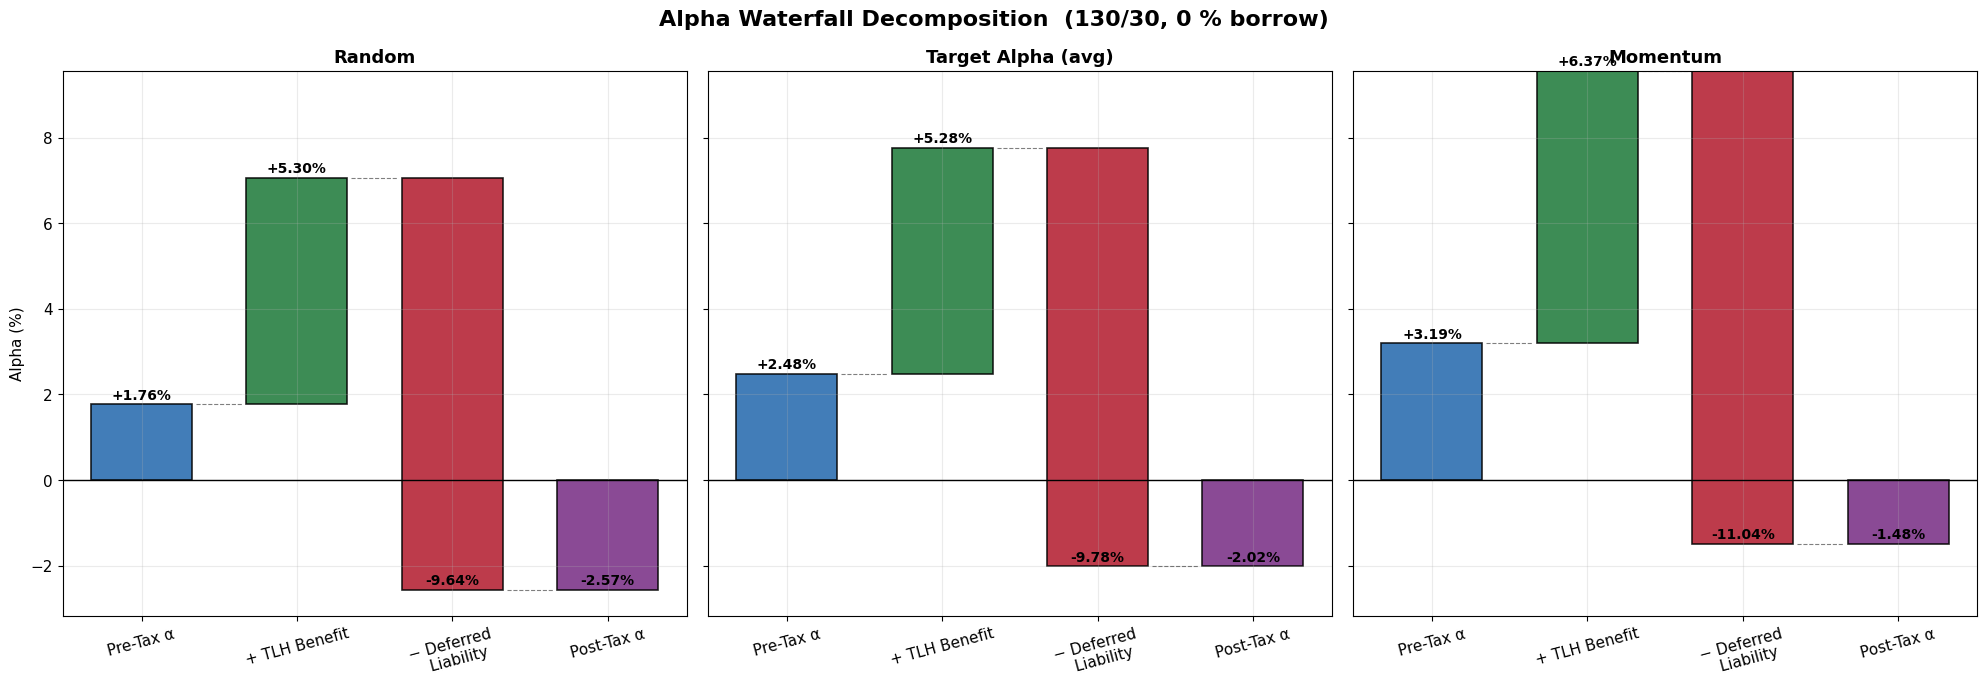

In [19]:
# =============================================================================
# 6b. WATERFALL CHART: Alpha Decomposition by Strategy
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle('Alpha Waterfall Decomposition  (130/30, 0 % borrow)', fontsize=16, fontweight='bold')

for ax, (label, data) in zip(axes, [
    ('Random', rc), ('Target Alpha (avg)', tc), ('Momentum', mc)
]):
    pretax    = data['alpha_pretax'].mean() * 100
    tlh_ben   = (data['tax_benefit'].mean() / CAPITAL) * 100
    defer_lia = -(data['deferred_liability'].mean() / CAPITAL) * 100
    borrow    = 0.0  # already filtered to 0% borrow
    posttax   = data['alpha_posttax'].mean() * 100

    steps   = ['Pre-Tax α', '+ TLH Benefit', '− Deferred\n  Liability', 'Post-Tax α']
    vals    = [pretax, tlh_ben, defer_lia, posttax]
    bottoms = [0, pretax, pretax + tlh_ben, 0]
    colors  = [COLORS['blue'], COLORS['green'], COLORS['red'], COLORS['purple']]

    bars = ax.bar(steps, vals, bottom=bottoms, color=colors, edgecolor='black',
                  linewidth=1.2, width=0.65, alpha=0.85)

    # value labels
    for bar, v, b in zip(bars, vals, bottoms):
        y = b + v
        ax.text(bar.get_x() + bar.get_width()/2, y + 0.05,
                f'{v:+.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # connector lines
    for i in range(len(steps) - 1):
        y_conn = bottoms[i] + vals[i]
        ax.plot([i + 0.35, i + 0.65], [y_conn, y_conn], 'k--', lw=0.8, alpha=0.5)

    ax.axhline(0, color='black', lw=1)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Alpha (%)' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Pre-Tax vs Post-Tax Alpha: All Strategies

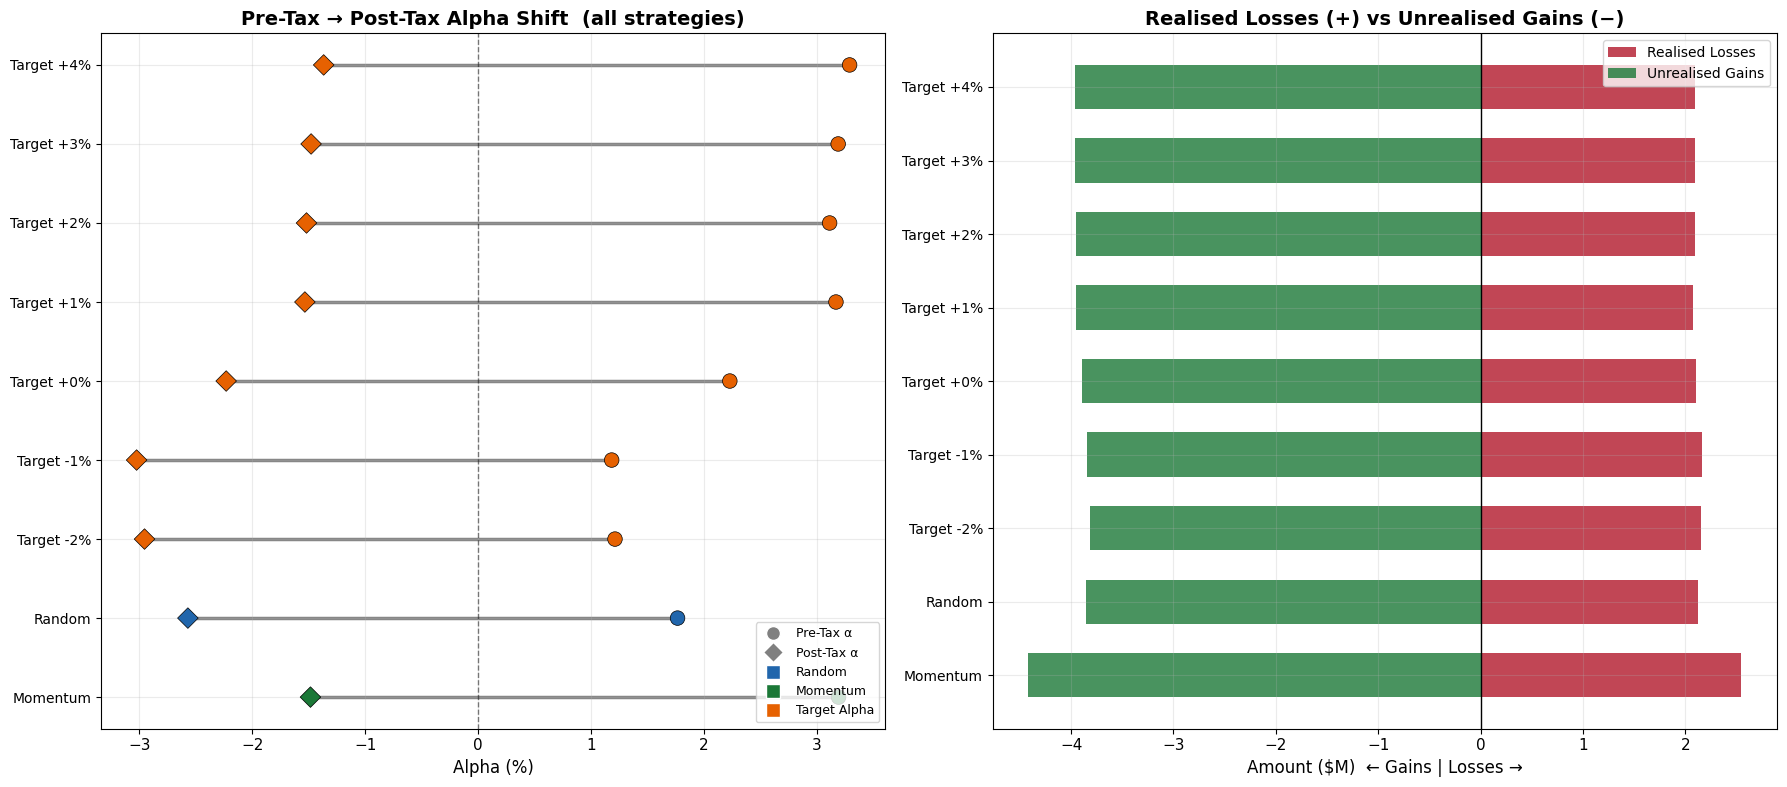

In [20]:
# =============================================================================
# 6c. DUMBBELL / DOT CHART: Pre-Tax ↔ Post-Tax Alpha — ALL STRATEGIES
# =============================================================================

# --- Build unified row set: target alpha rows + aggregate Random + aggregate Momentum ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]
grp_t = ts.groupby('target_alpha').agg(
    pre=('alpha_pretax','mean'), post=('alpha_posttax','mean'),
    rl=('realized_losses','mean'), ug=('unrealized_gains','mean')
).reset_index()
grp_t['label'] = [f'Target {t:+.0%}' for t in grp_t['target_alpha']]
grp_t['color_dot'] = COLORS['orange']

# Random aggregate
rc = _filt(df_random)
row_rand = pd.DataFrame([{
    'label': 'Random', 'pre': rc['alpha_pretax'].mean(), 'post': rc['alpha_posttax'].mean(),
    'rl': rc['realized_losses'].mean(), 'ug': rc['unrealized_gains'].mean(),
    'color_dot': COLORS['blue'],
}])

# Momentum aggregate
mc = _filt(df_momentum)
row_mom = pd.DataFrame([{
    'label': 'Momentum', 'pre': mc['alpha_pretax'].mean(), 'post': mc['alpha_posttax'].mean(),
    'rl': mc['realized_losses'].mean(), 'ug': mc['unrealized_gains'].mean(),
    'color_dot': COLORS['green'],
}])

grp = pd.concat([row_mom, row_rand, grp_t], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---- LEFT: Dumbbell — pre vs post-tax alpha ----
ax = axes[0]
y = np.arange(len(grp))

for i in range(len(grp)):
    ax.plot([grp['pre'].iloc[i]*100, grp['post'].iloc[i]*100], [i, i],
            color=COLORS['gray'], lw=2.5, zorder=1)

ax.scatter(grp['pre']*100,  y, s=110, color=[c for c in grp['color_dot']], zorder=2,
           marker='o', edgecolors='black', linewidth=0.5, label='Pre-Tax α')
ax.scatter(grp['post']*100, y, s=110, color=[c for c in grp['color_dot']], zorder=2,
           marker='D', edgecolors='black', linewidth=0.5, label='Post-Tax α')

# Legend markers (use proxy artists)
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Pre-Tax α'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='gray', markersize=10, label='Post-Tax α'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=COLORS['blue'],   markersize=10, label='Random'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=COLORS['green'],  markersize=10, label='Momentum'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=COLORS['orange'], markersize=10, label='Target Alpha'),
]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')

ax.set_yticks(y)
ax.set_yticklabels(grp['label'], fontsize=10)
ax.set_xlabel('Alpha (%)', fontsize=12)
ax.set_title('Pre-Tax → Post-Tax Alpha Shift  (all strategies)', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)

# ---- RIGHT: Diverging bar — realised losses vs unrealised gains ----
ax2 = axes[1]
w = 0.6
ax2.barh(y, grp['rl']/1e6, height=w, color=COLORS['red'],   alpha=0.8, label='Realised Losses')
ax2.barh(y, -grp['ug']/1e6, height=w, color=COLORS['green'], alpha=0.8, label='Unrealised Gains')
ax2.set_yticks(y)
ax2.set_yticklabels(grp['label'], fontsize=10)
ax2.set_xlabel('Amount ($M)  ← Gains | Losses →', fontsize=12)
ax2.set_title('Realised Losses (+) vs Unrealised Gains (−)', fontsize=14, fontweight='bold')
ax2.axvline(0, color='black', lw=1)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


### Alpha vs TLH Relationship

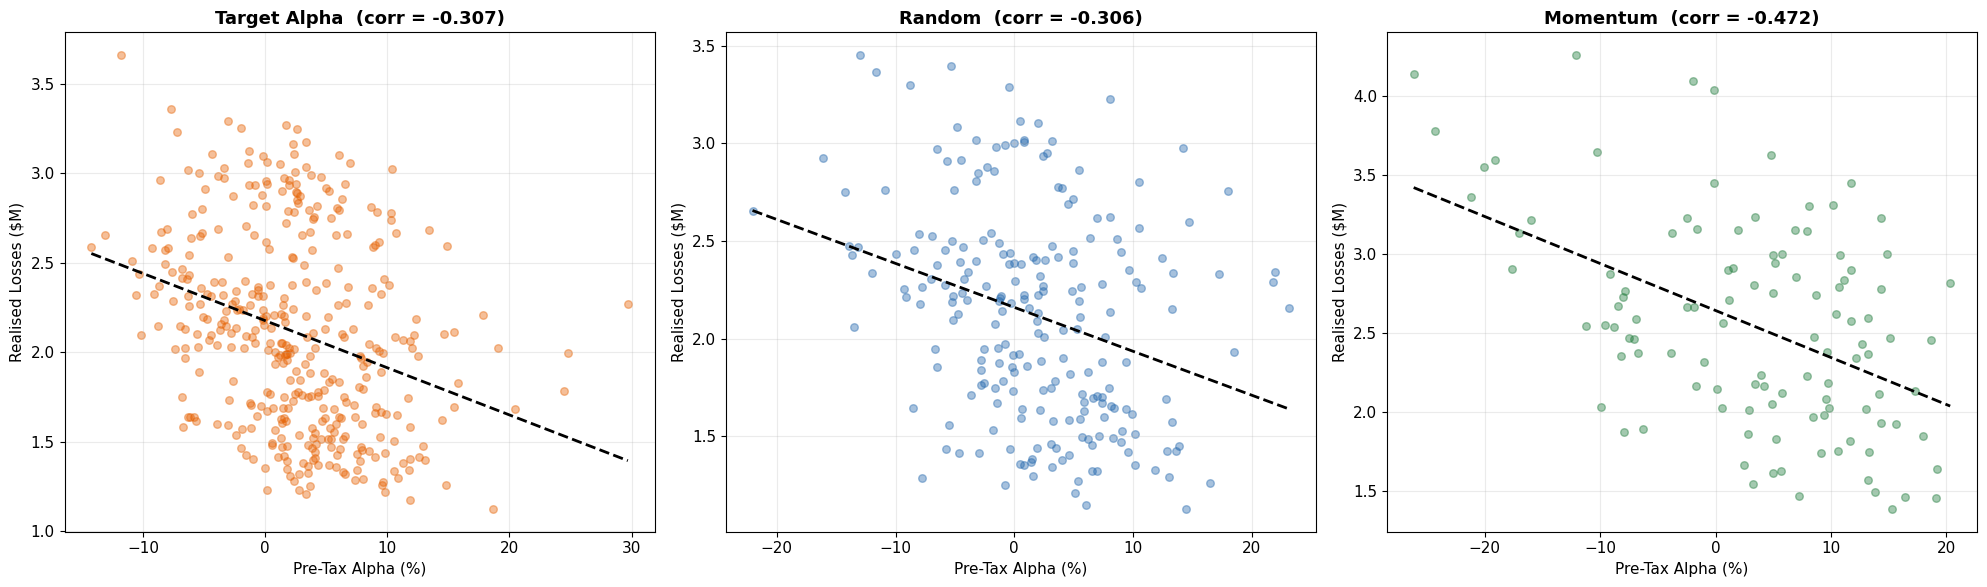

In [21]:
# =============================================================================
# 6d. SCATTER: Alpha vs Realised Losses  (Target + Random)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (label, data, c) in zip(axes, [
    ('Target Alpha', _filt(df_target), COLORS['orange']),
    ('Random',       _filt(df_random), COLORS['blue']),
    ('Momentum',     _filt(df_momentum), COLORS['green']),
]):
    x = data['alpha_pretax'].values * 100
    y = data['realized_losses'].values / 1e6
    ax.scatter(x, y, alpha=0.4, s=30, c=c)

    # trend line
    z = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k--', lw=2)

    corr = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel('Pre-Tax Alpha (%)')
    ax.set_ylabel('Realised Losses ($M)')
    ax.set_title(f'{label}  (corr = {corr:.3f})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Leverage × Borrowing Rate: Post-Tax Alpha Heatmaps

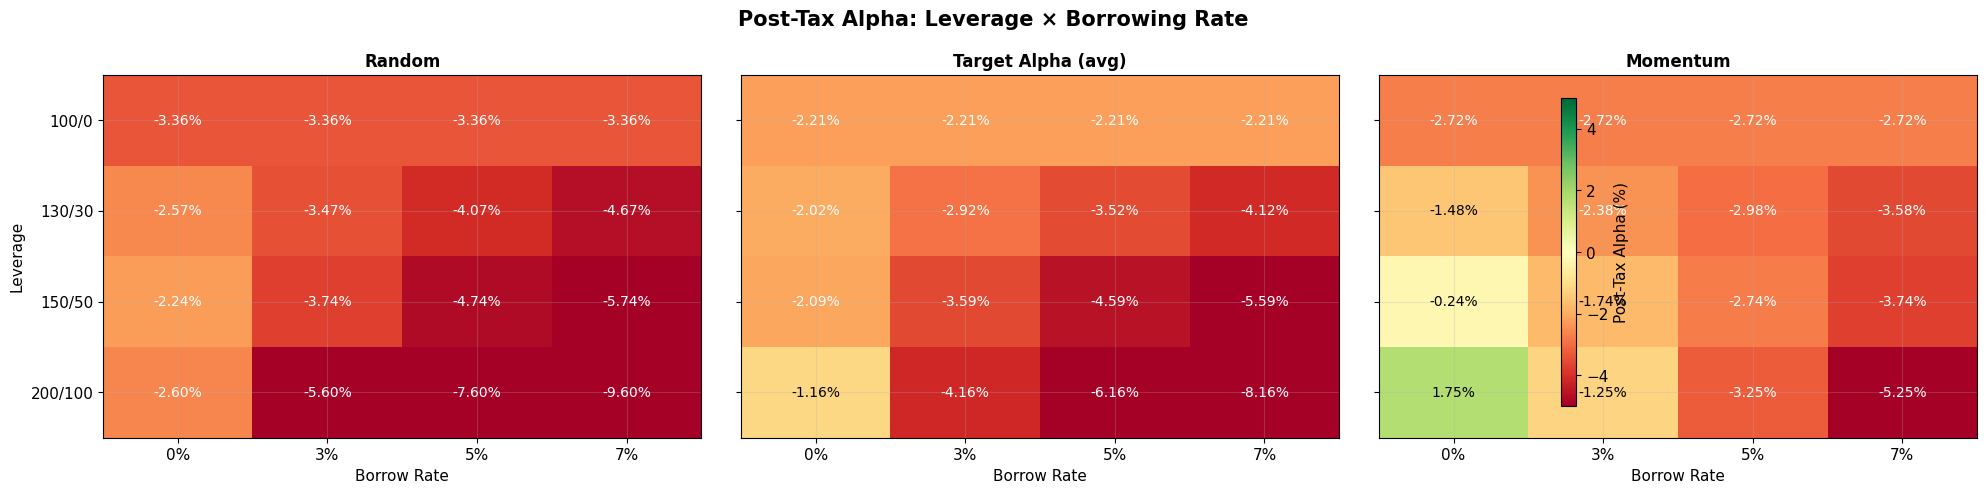

In [22]:
# =============================================================================
# 6e. HEATMAP: Post-Tax Alpha by Leverage × Borrow Rate  (all 3 strategies)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
fig.suptitle('Post-Tax Alpha: Leverage × Borrowing Rate', fontsize=15, fontweight='bold')

lev_order = ['100/0','130/30','150/50','200/100']

for ax, (label, data) in zip(axes, [
    ('Random', df_random), ('Target Alpha (avg)', df_target), ('Momentum', df_momentum)
]):
    piv = data.groupby(['leverage_label','borrowing_rate'])['alpha_posttax'].mean().unstack()
    piv = piv.reindex(lev_order)
    im = ax.imshow(piv.values*100, cmap='RdYlGn', aspect='auto',
                   vmin=-5, vmax=5)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'{c:.0%}' for c in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]*100
            ax.text(j, i, f'{v:.2f}%', ha='center', va='center',
                    fontsize=10, color='white' if abs(v)>2 else 'black')
    ax.set_xlabel('Borrow Rate')
    if ax == axes[0]: ax.set_ylabel('Leverage')
    ax.set_title(label, fontsize=12, fontweight='bold')

fig.colorbar(im, ax=axes, label='Post-Tax Alpha (%)', shrink=0.8)
plt.tight_layout()
plt.show()

### Year-Over-Year TLH Trends

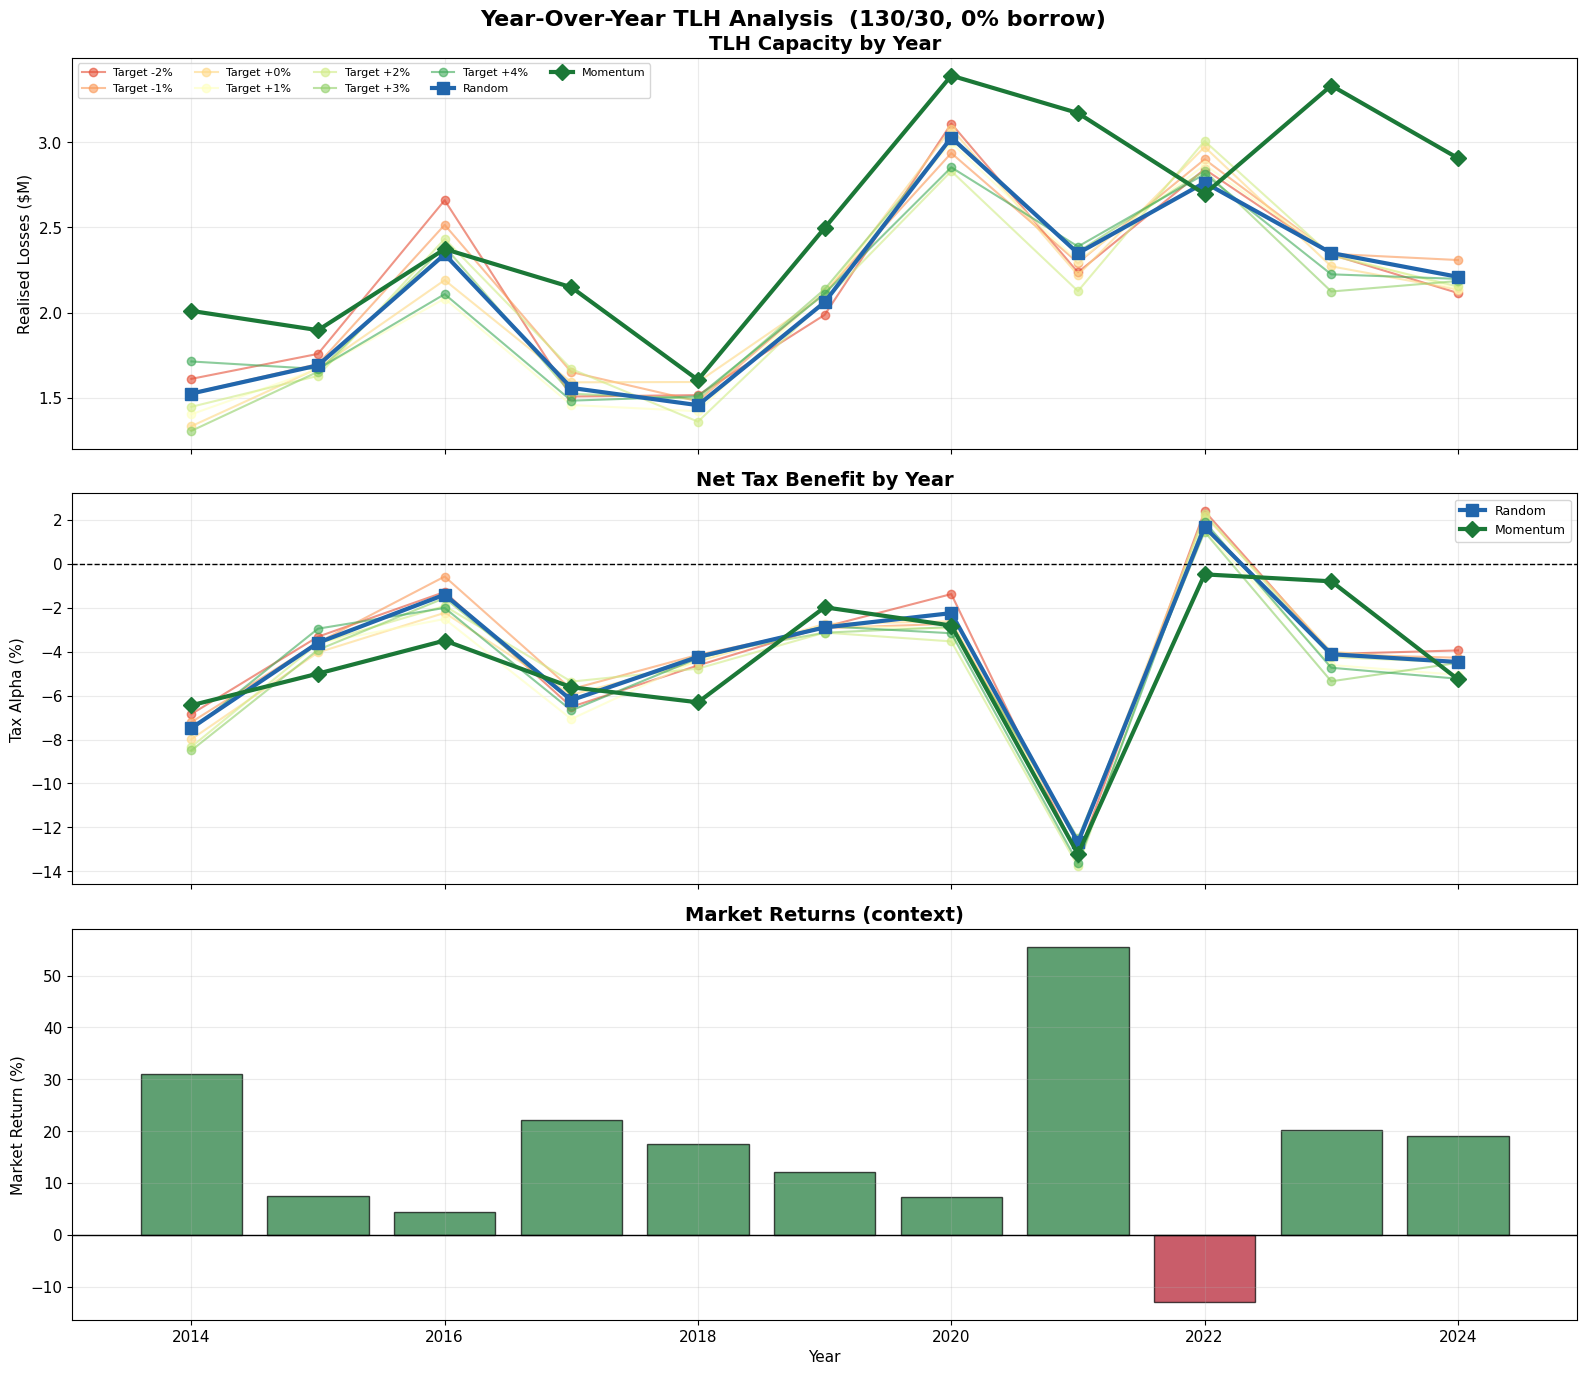

In [23]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]
yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: Realised Losses by Year ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['rl']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['rl']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['rl']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('Realised Losses ($M)')
ax1.set_title('TLH Capacity by Year', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: Tax Alpha by Year ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax2.plot(sub['year'], sub['ta']*100, 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd['year'], rd['ta']*100, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md['year'], md['ta']*100, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_ylabel('Tax Alpha (%)')
ax2.set_title('Net Tax Benefit by Year', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Leverage Impact: Losses vs Gains by Leverage

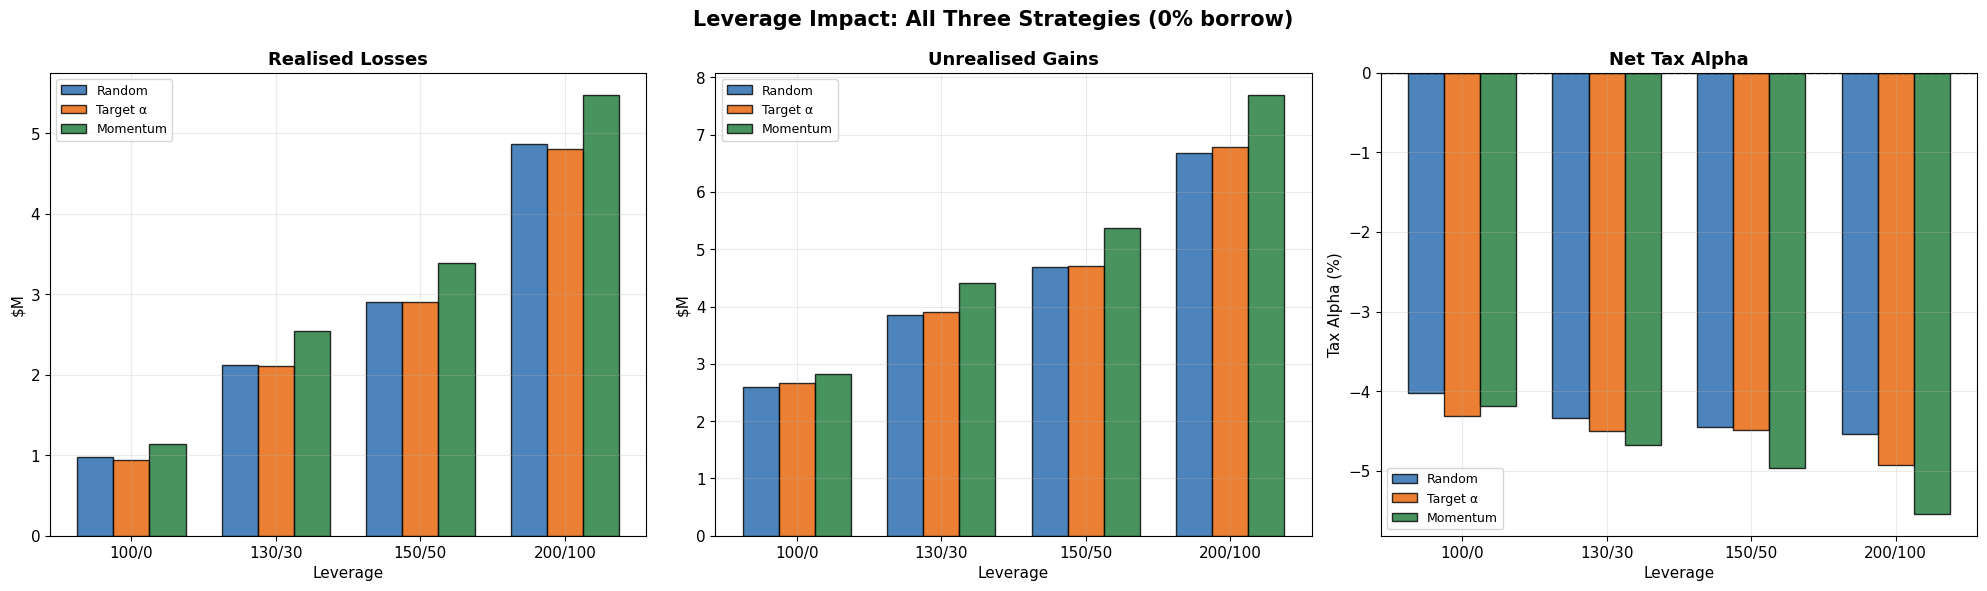

In [24]:
# =============================================================================
# 6g. LEVERAGE IMPACT: All Three Strategies Side-by-Side
# =============================================================================

lev_order = ['100/0', '130/30', '150/50', '200/100']

def _lev_agg(df_in):
    return df_in[df_in['borrowing_rate']==0.0].groupby('leverage_label').agg(
        rl=('realized_losses','mean'), ug=('unrealized_gains','mean'),
        ta=('tax_alpha','mean')
    ).reindex(lev_order)

lr = _lev_agg(df_random)
lt = _lev_agg(df_target)
lm = _lev_agg(df_momentum)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('Leverage Impact: All Three Strategies (0% borrow)', fontsize=15, fontweight='bold')

x = np.arange(len(lev_order))
w = 0.25

# ---- LEFT: Realised Losses by Leverage ----
ax1 = axes[0]
ax1.bar(x - w, lr['rl']/1e6, w, color=COLORS['blue'],   alpha=0.8, label='Random',    edgecolor='black')
ax1.bar(x,     lt['rl']/1e6, w, color=COLORS['orange'], alpha=0.8, label='Target α',  edgecolor='black')
ax1.bar(x + w, lm['rl']/1e6, w, color=COLORS['green'],  alpha=0.8, label='Momentum',  edgecolor='black')
ax1.set_xticks(x); ax1.set_xticklabels(lev_order)
ax1.set_xlabel('Leverage'); ax1.set_ylabel('$M')
ax1.set_title('Realised Losses', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# ---- MIDDLE: Unrealised Gains by Leverage ----
ax2 = axes[1]
ax2.bar(x - w, lr['ug']/1e6, w, color=COLORS['blue'],   alpha=0.8, label='Random',    edgecolor='black')
ax2.bar(x,     lt['ug']/1e6, w, color=COLORS['orange'], alpha=0.8, label='Target α',  edgecolor='black')
ax2.bar(x + w, lm['ug']/1e6, w, color=COLORS['green'],  alpha=0.8, label='Momentum',  edgecolor='black')
ax2.set_xticks(x); ax2.set_xticklabels(lev_order)
ax2.set_xlabel('Leverage'); ax2.set_ylabel('$M')
ax2.set_title('Unrealised Gains', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

# ---- RIGHT: Net Tax Alpha by Leverage ----
ax3 = axes[2]
ax3.bar(x - w, lr['ta']*100, w, color=COLORS['blue'],   alpha=0.8, label='Random',    edgecolor='black')
ax3.bar(x,     lt['ta']*100, w, color=COLORS['orange'], alpha=0.8, label='Target α',  edgecolor='black')
ax3.bar(x + w, lm['ta']*100, w, color=COLORS['green'],  alpha=0.8, label='Momentum',  edgecolor='black')
ax3.set_xticks(x); ax3.set_xticklabels(lev_order)
ax3.set_xlabel('Leverage'); ax3.set_ylabel('Tax Alpha (%)')
ax3.set_title('Net Tax Alpha', fontsize=13, fontweight='bold')
ax3.axhline(0, color='black', lw=1, ls='--')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Volatility vs TLH Capacity

**Hypothesis**: Higher portfolio volatility should generate more tax loss harvesting opportunities, 
because more positions will experience losses large enough to trigger harvesting.

This analysis calculates each portfolio's realised volatility (annualised standard deviation of monthly returns) 
and examines its relationship with TLH capacity (realised losses).


VOLATILITY vs TLH RELATIONSHIP

Summary by Strategy (130/30, 0% borrow):


,avg_volatility,avg_tlh,avg_unrealized,correlation
strategy,,,,
Momentum,5.66%,"$2,548,131","$4,417,900",0.548
Random,6.29%,"$2,121,099","$3,854,828",0.340
Target Alpha,5.17%,"$2,111,456","$3,910,277",0.162


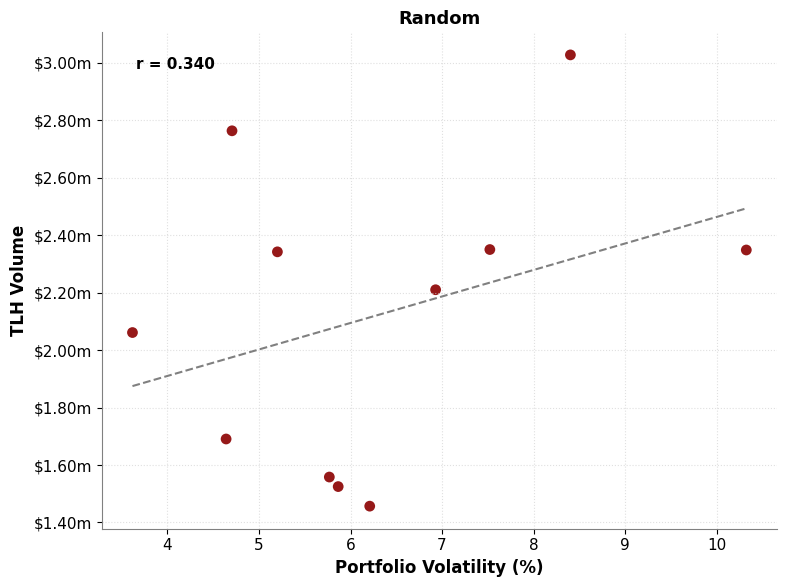

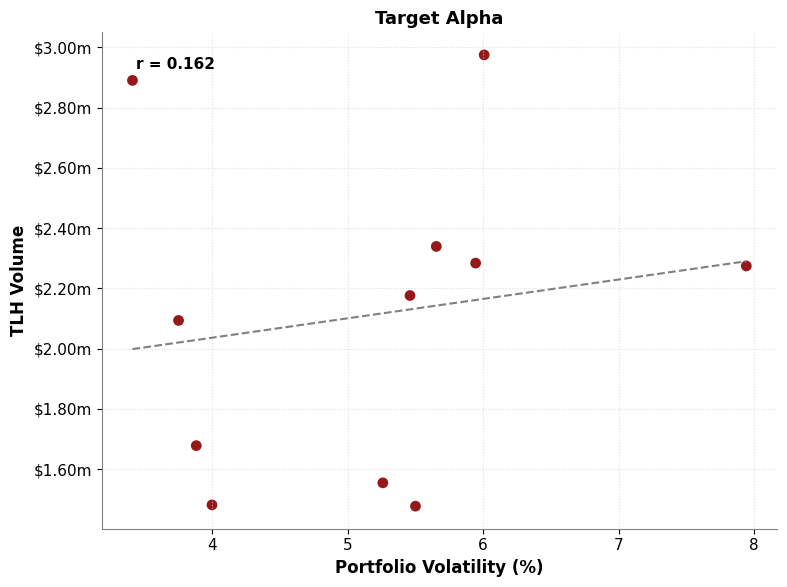

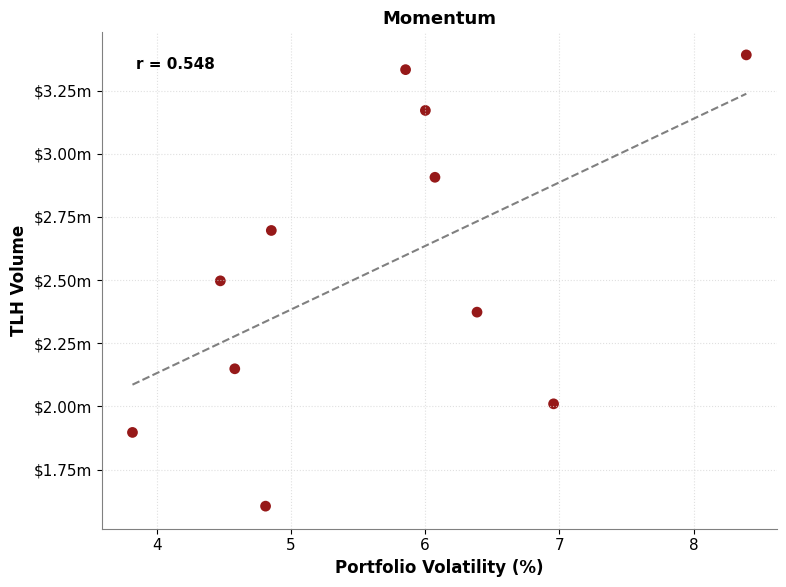


Market Conditions vs TLH:
Using absolute market return as volatility proxy (higher abs return = more volatile year)
Correlation (|Market Return| vs Avg TLH): -0.040


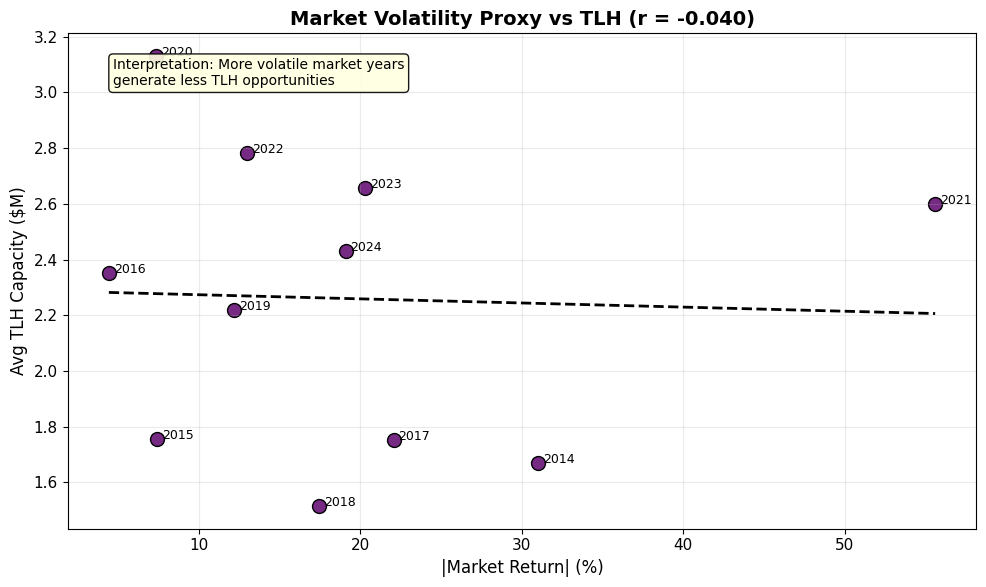

In [25]:
# =============================================================================
# 6h. VOLATILITY vs TLH CAPACITY ANALYSIS
# =============================================================================

# We need to compute portfolio volatility from the simulation.
# Since we don't store monthly returns in results, we'll compute it by re-running
# a subset OR we can proxy volatility using the spread of returns across portfolios.

# APPROACH: Use cross-sectional volatility of portfolio returns as a proxy
# Group by year and compute std of portfolio returns within each config

def compute_volatility_tlh_relationship(df_in, label):
    """Compute volatility metrics for a strategy's results."""
    # Volatility proxy: std of portfolio returns within each (year, leverage) group
    # This captures how much dispersion exists - higher dispersion = higher vol environment
    
    rows = []
    for (lev, br), grp in df_in.groupby(['leverage_label', 'borrowing_rate']):
        for year, ygrp in grp.groupby('year'):
            vol = ygrp['port_return'].std()  # Cross-portfolio vol
            avg_ret = ygrp['port_return'].mean()
            avg_tlh = ygrp['realized_losses'].mean()
            avg_ug  = ygrp['unrealized_gains'].mean()
            mkt_ret = ygrp['market_return'].iloc[0]
            
            rows.append({
                'strategy': label,
                'leverage': lev,
                'borrow_rate': br,
                'year': year,
                'volatility': vol,
                'avg_return': avg_ret,
                'avg_tlh': avg_tlh,
                'avg_unrealized': avg_ug,
                'market_return': mkt_ret,
                'abs_market': abs(mkt_ret),
            })
    return pd.DataFrame(rows)

vol_random   = compute_volatility_tlh_relationship(df_random, 'Random')
vol_target   = compute_volatility_tlh_relationship(df_target, 'Target Alpha')
vol_momentum = compute_volatility_tlh_relationship(df_momentum, 'Momentum')

vol_all = pd.concat([vol_random, vol_target, vol_momentum], ignore_index=True)

# Filter to standard config for cleaner analysis
vol_std = vol_all[(vol_all['leverage']=='130/30') & (vol_all['borrow_rate']==0.0)]

# ---- TABLE: Volatility vs TLH by Strategy ----
print('VOLATILITY vs TLH RELATIONSHIP')
print('='*70)

vol_summary = vol_std.groupby('strategy').agg(
    avg_volatility = ('volatility', 'mean'),
    avg_tlh        = ('avg_tlh', 'mean'),
    avg_unrealized = ('avg_unrealized', 'mean'),
    correlation    = ('volatility', lambda x: vol_std.loc[x.index, ['volatility','avg_tlh']].corr().iloc[0,1]),
).round(4)

# Compute correlation properly
for strat in vol_summary.index:
    mask = vol_std['strategy'] == strat
    corr = vol_std.loc[mask, 'volatility'].corr(vol_std.loc[mask, 'avg_tlh'])
    vol_summary.loc[strat, 'correlation'] = corr

print('\nSummary by Strategy (130/30, 0% borrow):')
display(vol_summary.style.format({
    'avg_volatility': '{:.2%}',
    'avg_tlh': '${:,.0f}',
    'avg_unrealized': '${:,.0f}',
    'correlation': '{:.3f}',
}))

# ---- GRAPH: Scatter + Regression (one figure per strategy, reference style) ----
# Style: white background, dark red markers, light gray axes, dotted grid, dark bold labels
SCATTER_COLOR = '#8B0000'
AXES_COLOR = '#808080'
GRID_COLOR = '#d3d3d3'

for strat in ['Random', 'Target Alpha', 'Momentum']:
    data = vol_std[vol_std['strategy'] == strat]
    x = data['volatility'].values * 100  # as percentage
    y = data['avg_tlh'].values / 1e6     # as $M

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.scatter(x, y, s=60, c=SCATTER_COLOR, edgecolors='none', alpha=0.9)

    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, np.polyval(z, xl), color=AXES_COLOR, linestyle='--', lw=1.5)
        corr = np.corrcoef(x, y)[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top', color='black')

    ax.set_xlabel('Portfolio Volatility (%)', fontsize=12, fontweight='bold', color='black')
    ax.set_ylabel('TLH Volume', fontsize=12, fontweight='bold', color='black')
    ax.set_title(strat, fontsize=13, fontweight='bold', color='black')
    ax.tick_params(colors='black')
    ax.spines['bottom'].set_color(AXES_COLOR)
    ax.spines['left'].set_color(AXES_COLOR)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', color=GRID_COLOR, linewidth=0.8, alpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.2f}m'))
    plt.tight_layout()
    plt.show()

# ---- Additional: Market volatility proxy vs TLH ----
print('\nMarket Conditions vs TLH:')
print('Using absolute market return as volatility proxy (higher abs return = more volatile year)')

mkt_tlh = vol_std.groupby('year').agg(
    abs_market = ('abs_market', 'first'),
    avg_tlh    = ('avg_tlh', 'mean'),
).reset_index()

corr_mkt = mkt_tlh['abs_market'].corr(mkt_tlh['avg_tlh'])
print(f'Correlation (|Market Return| vs Avg TLH): {corr_mkt:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mkt_tlh['abs_market']*100, mkt_tlh['avg_tlh']/1e6, 
           s=100, c=COLORS['purple'], edgecolors='black', linewidth=1)

for _, row in mkt_tlh.iterrows():
    ax.annotate(str(int(row['year'])), 
                (row['abs_market']*100 + 0.3, row['avg_tlh']/1e6),
                fontsize=9)

# Trend
x, y = mkt_tlh['abs_market'].values*100, mkt_tlh['avg_tlh'].values/1e6
z = np.polyfit(x, y, 1)
xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k--', lw=2)

ax.set_xlabel('|Market Return| (%)', fontsize=12)
ax.set_ylabel('Avg TLH Capacity ($M)', fontsize=12)
ax.set_title(f'Market Volatility Proxy vs TLH (r = {corr_mkt:.3f})', fontsize=14, fontweight='bold')
ax.text(0.05, 0.95, f'Interpretation: More volatile market years\ngenerate {"more" if corr_mkt > 0 else "less"} TLH opportunities',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()


---
# Part 7 — Sector Deep-Dive: Where Does TLH Come From?

In [26]:
# =============================================================================
# 7a. SECTOR TLH ATTRIBUTION — All Three Strategies
# =============================================================================

def _extract_sector_tlh(df_in, strategy_name):
    """Extract sector-level TLH from a filtered DataFrame."""
    rows = []
    for _, r in _filt(df_in).iterrows():
        h = r.get('harvest_by_sector', {})
        if isinstance(h, dict):
            for sec, amt in h.items():
                if sec and sec != 'Unknown':
                    rows.append({'Sector': sec, 'TLH': amt, 'Year': r['year'], 'Strategy': strategy_name})
    return rows

sector_rows  = _extract_sector_tlh(df_random,   'Random')
sector_rows += _extract_sector_tlh(df_target,   'Target Alpha')
sector_rows += _extract_sector_tlh(df_momentum, 'Momentum')

sdf_all = pd.DataFrame(sector_rows)

if len(sdf_all) > 0:
    # Overall ranking (all strategies combined)
    ss = sdf_all.groupby('Sector')['TLH'].agg(['mean','sum']).round(0)
    ss['% of Total'] = (ss['sum'] / ss['sum'].sum() * 100).round(1)
    ss = ss.sort_values('% of Total', ascending=False)
    ss.columns = ['Avg TLH ($)', 'Total TLH ($)', '% of Total']

    # Per-strategy breakdown
    ss_by_strat = sdf_all.groupby(['Sector','Strategy'])['TLH'].mean().unstack(fill_value=0)
    ss_by_strat = ss_by_strat.reindex(ss.index)  # same sector order

    print('SECTOR TLH ATTRIBUTION  (130/30, 0% borrow, all strategies)')
    print('='*70)
    display(ss.style.format({
        'Avg TLH ($)':'${:,.0f}', 'Total TLH ($)':'${:,.0f}', '% of Total':'{:.1f}%'
    }).background_gradient(subset=['% of Total'], cmap='OrRd'))

    print('\nPER-STRATEGY SECTOR BREAKDOWN (Avg TLH $):')
    display(ss_by_strat.style.format('${:,.0f}').background_gradient(cmap='YlOrRd', axis=None))


SECTOR TLH ATTRIBUTION  (130/30, 0% borrow, all strategies)


,Avg TLH ($),Total TLH ($),% of Total
Sector,,,
Information Technology,"$264,855","$189,371,241",17.4%
Financials,"$206,908","$147,939,056",13.6%
Consumer Discretionary,"$198,550","$141,963,391",13.1%
Industrials,"$197,525","$141,230,668",13.0%
Health Care,"$195,364","$139,685,172",12.9%
Energy,"$106,778","$76,133,025",7.0%
Communication Services,"$81,884","$58,219,672",5.4%
Real Estate,"$80,670","$57,194,873",5.3%
Consumer Staples,"$73,128","$52,213,311",4.8%



PER-STRATEGY SECTOR BREAKDOWN (Avg TLH $):


Strategy,Momentum,Random,Target Alpha
Sector,,,
Information Technology,"$353,459","$247,372","$249,529"
Financials,"$153,216","$213,918","$218,243"
Consumer Discretionary,"$268,084","$183,732","$187,151"
Industrials,"$191,462","$193,869","$201,347"
Health Care,"$301,220","$184,609","$171,265"
Energy,"$163,969","$99,372","$94,788"
Communication Services,"$130,070","$75,015","$71,939"
Real Estate,"$43,700","$87,364","$86,831"
Consumer Staples,"$79,398","$72,398","$71,770"


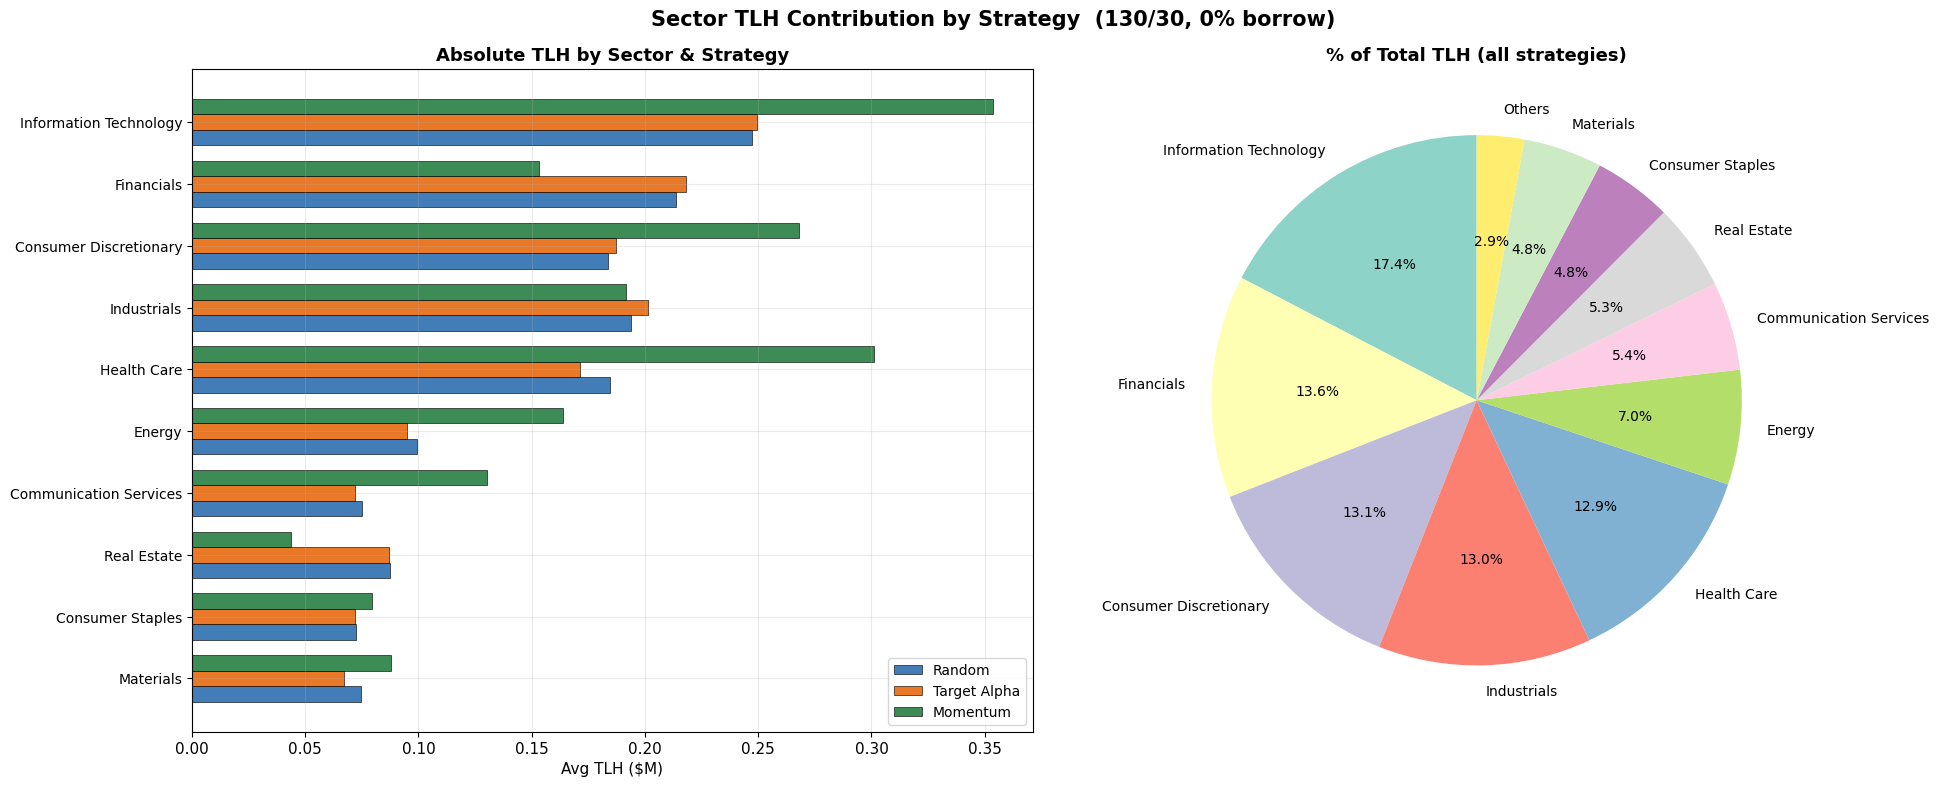

In [27]:
# =============================================================================
# 7b. SECTOR VISUALISATIONS — All Three Strategies
# =============================================================================

if len(sdf_all) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('Sector TLH Contribution by Strategy  (130/30, 0% borrow)',
                 fontsize=15, fontweight='bold')

    top_sectors = ss.head(10).index.tolist()

    # ---- LEFT: Grouped horizontal bar — by strategy ----
    ax1 = axes[0]
    strat_means = sdf_all[sdf_all['Sector'].isin(top_sectors)].groupby(
        ['Sector','Strategy'])['TLH'].mean().unstack(fill_value=0)
    strat_means = strat_means.reindex(top_sectors[::-1])  # top at top
    
    y_pos = np.arange(len(strat_means))
    bw = 0.25
    for j, (strat, col) in enumerate([
        ('Random', COLORS['blue']), ('Target Alpha', COLORS['orange']), ('Momentum', COLORS['green'])
    ]):
        if strat in strat_means.columns:
            ax1.barh(y_pos + j*bw, strat_means[strat]/1e6, height=bw,
                     color=col, alpha=0.85, edgecolor='black', linewidth=0.5, label=strat)

    ax1.set_yticks(y_pos + bw)
    ax1.set_yticklabels(strat_means.index, fontsize=10)
    ax1.set_xlabel('Avg TLH ($M)')
    ax1.set_title('Absolute TLH by Sector & Strategy', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)

    # ---- RIGHT: Pie chart — overall % contribution ----
    ax2 = axes[1]
    top_pct = ss.head(10)
    others  = ss.iloc[10:]['% of Total'].sum() if len(ss) > 10 else 0
    pct_v   = list(top_pct['% of Total'].values)
    pct_l   = list(top_pct.index)
    if others > 0:
        pct_v.append(others); pct_l.append('Others')
    ax2.pie(pct_v, labels=pct_l, autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, len(pct_v))),
            textprops={'fontsize': 10})
    ax2.set_title('% of Total TLH (all strategies)', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()


---
# Final Summary

In [28]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

rc, tc, mc = _filt(df_random), _filt(df_target), _filt(df_momentum)

print('='*70)
print('FINAL SUMMARY — MONTHLY TLH ANALYSIS')
print('='*70)

print('\n1. TARGET ALPHA RESULTS  (130/30, 0% borrow):')
for _, row in target_summary.iterrows():
    print(f'   {row.name}: Harvested=${row["realized_losses"]:,.0f}  '
          f'α Taxes={row["alpha_taxes"]:.2%}  TLH Adv={row["tlh_advantage"]:.2%}  '
          f'Final α={row["final_alpha"]:.2%}')

print(f'\n2. RANDOM  (130/30, 0% borrow):')
rm = rc.select_dtypes(include='number').mean()
print(f'   Return={rm["port_return"]:.2%}  α vs Mkt={rm["alpha_pretax"]:.2%}  '
      f'Losses=${rm["realized_losses"]:,.0f}  Gains=${rm["unrealized_gains"]:,.0f}  '
      f'Final α={rm["alpha_posttax"]:.2%}')

print(f'\n3. MOMENTUM  (130/30, 0% borrow):')
mm = mc.select_dtypes(include='number').mean()
print(f'   Return={mm["port_return"]:.2%}  α vs Mkt={mm["alpha_pretax"]:.2%}  '
      f'Losses=${mm["realized_losses"]:,.0f}  Gains=${mm["unrealized_gains"]:,.0f}  '
      f'Final α={mm["alpha_posttax"]:.2%}')

print('\n4. KEY INSIGHTS:')
print('   • Negative-alpha portfolios harvest the most losses (highest TLH)')
print('   • Positive-alpha portfolios accumulate unrealised gains (deferred liability)')
print('   • α from Taxes = (Realised Losses × 25% − Unrealised Gains × 25%) / Capital')
print('   • TLH Advantage = gross tax savings from harvesting (before deferred liability)')
print('   • Higher leverage amplifies both losses and gains — net effect depends on market')
print('   • Borrowing costs erode tax benefit at high leverage')

if len(sdf_all) > 0:
    print(f'\n5. TOP SECTORS FOR TLH:')
    for i, (sec, row) in enumerate(ss.head(5).iterrows()):
        print(f'   {i+1}. {sec}: ${row["Avg TLH ($)"]:,.0f} ({row["% of Total"]:.1f}%)')


FINAL SUMMARY — MONTHLY TLH ANALYSIS

1. TARGET ALPHA RESULTS  (130/30, 0% borrow):
   -2%: Harvested=$2,152,885  α Taxes=-4.16%  TLH Adv=5.38%  Final α=-2.95%
   -1%: Harvested=$2,161,277  α Taxes=-4.21%  TLH Adv=5.40%  Final α=-3.02%
   +0%: Harvested=$2,105,883  α Taxes=-4.46%  TLH Adv=5.26%  Final α=-2.23%
   +1%: Harvested=$2,073,655  α Taxes=-4.70%  TLH Adv=5.18%  Final α=-1.53%
   +2%: Harvested=$2,096,398  α Taxes=-4.63%  TLH Adv=5.24%  Final α=-1.52%
   +3%: Harvested=$2,092,739  α Taxes=-4.67%  TLH Adv=5.23%  Final α=-1.48%
   +4%: Harvested=$2,097,351  α Taxes=-4.66%  TLH Adv=5.24%  Final α=-1.37%

2. RANDOM  (130/30, 0% borrow):
   Return=18.48%  α vs Mkt=1.76%  Losses=$2,121,099  Gains=$3,854,828  Final α=-2.57%

3. MOMENTUM  (130/30, 0% borrow):
   Return=19.90%  α vs Mkt=3.19%  Losses=$2,548,131  Gains=$4,417,900  Final α=-1.48%

4. KEY INSIGHTS:
   • Negative-alpha portfolios harvest the most losses (highest TLH)
   • Positive-alpha portfolios accumulate unrealised gain

---

### Methodology Notes

- **Monthly rebalancing**: losers liquidated, winners held — asymmetric by design
- **Position scaling**: # positions ∝ leverage (200/100 has 2× positions vs 100/0)
- **Short P&L**: value compounds with stock return (fixed from prior version)
- **Dynamic leverage**: short notional scaled monthly to maintain target ratio
- **Momentum signal**: exponential-decay weighted returns (60-day lookback, λ = 0.95)
- **Tax rate**: 25 % flat on all gains / losses
- **Borrow cost**: (Long − 100%) × Capital × Rate; short proceeds are collateral

### Reading the Results

| Metric | Meaning |
|--------|--------|
| Pre-Tax Alpha | Portfolio Return − Market Return (before any tax effects) |
| Realised Losses | Cumulative harvested losses from losing positions |
| Unrealised Gains | Accumulated gains on held winners at year-end |
| Tax Benefit | Realised Losses × 25% |
| Deferred Liability | Unrealised Gains × 25% (tax owed when eventually sold) |
| Tax Alpha | (Tax Benefit − Deferred Liability) / Capital |
| Post-Tax Alpha | Pre-Tax α + Tax α − Borrow Cost % |

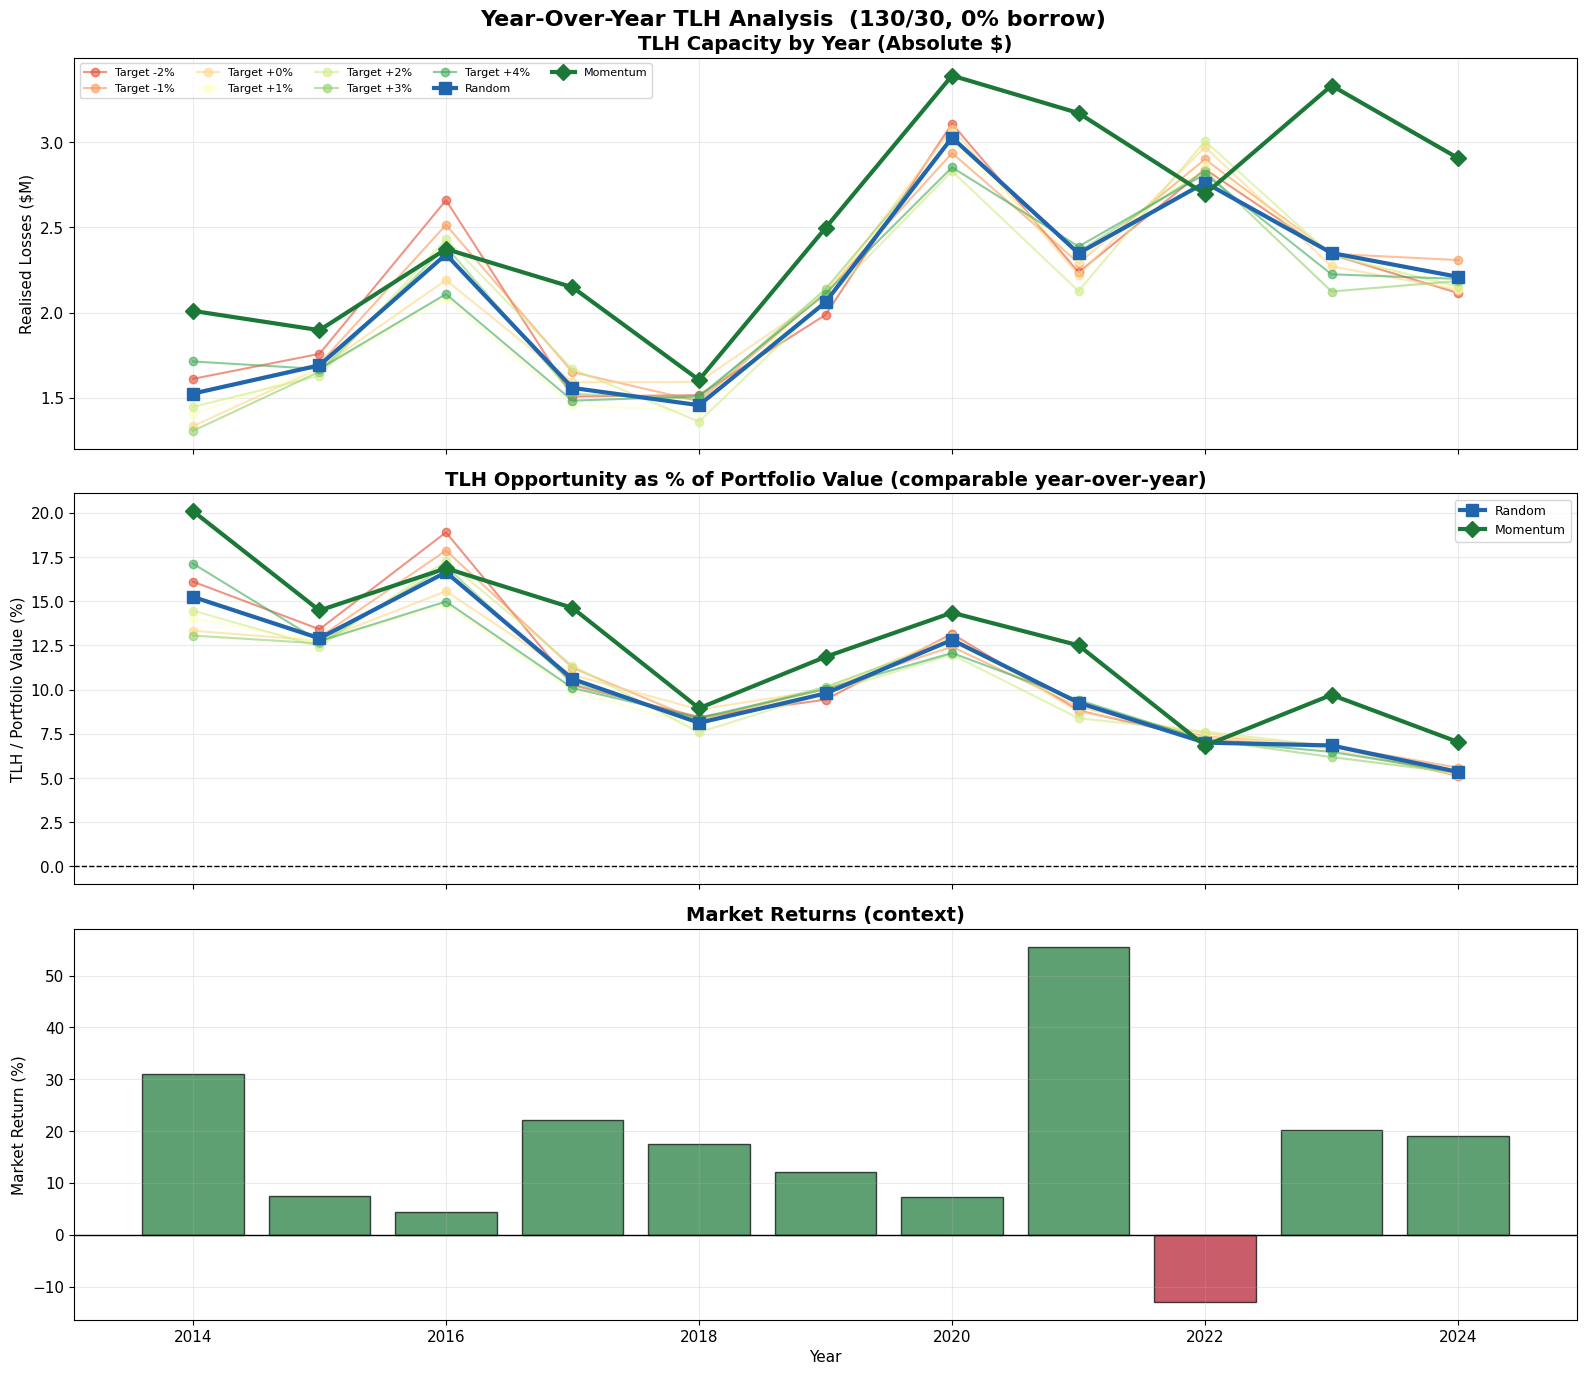

In [29]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

# For TLH %, we need cumulative portfolio value tracking
# Simplified: assume portfolio grows/shrinks with market each year
# Starting value = CAPITAL, then compounds with market return

def compute_tlh_pct(df_grouped):
    """Compute TLH as % of estimated portfolio value."""
    rows = []
    port_value = CAPITAL  # Starting portfolio value
    
    for year in sorted(df_grouped['year'].unique()):
        year_data = df_grouped[df_grouped['year'] == year]
        avg_rl = year_data['rl'].mean() if 'rl' in year_data.columns else year_data['realized_losses'].mean()
        avg_mkt = year_data['mkt'].mean() if 'mkt' in year_data.columns else year_data['market_return'].mean()
        
        # TLH as % of current portfolio value
        tlh_pct = (avg_rl / port_value) * 100
        
        rows.append({
            'year': year,
            'tlh_pct': tlh_pct,
            'port_value': port_value,
        })
        
        # Update portfolio value for next year (compounds with market)
        port_value = port_value * (1 + avg_mkt)
    
    return pd.DataFrame(rows)

# Prep aggregated data
yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

# Compute TLH % for Random and Momentum
rd_pct = compute_tlh_pct(rd)
md_pct = compute_tlh_pct(md)

# For target alpha, compute per target
target_pct_data = []
for t in sorted(TARGET_ALPHAS):
    sub = yd_t[yd_t['target_alpha']==t].copy()
    sub_pct = compute_tlh_pct(sub)
    sub_pct['target_alpha'] = t
    target_pct_data.append(sub_pct)
target_pct = pd.concat(target_pct_data, ignore_index=True)

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: Realised Losses by Year (absolute $) ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['rl']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['rl']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['rl']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('Realised Losses ($M)')
ax1.set_title('TLH Capacity by Year (Absolute $)', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: TLH as % of Portfolio Value ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = target_pct[target_pct['target_alpha']==t]
    ax2.plot(sub['year'], sub['tlh_pct'], 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd_pct['year'], rd_pct['tlh_pct'], 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md_pct['year'], md_pct['tlh_pct'], 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_ylabel('TLH / Portfolio Value (%)')
ax2.set_title('TLH Opportunity as % of Portfolio Value (comparable year-over-year)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Volatility vs TLH Capacity

**Hypothesis**: Higher portfolio volatility should generate more tax loss harvesting opportunities, 
because more positions will experience losses large enough to trigger harvesting.

---

#### Volatility Calculation Methodology

We measure volatility using two approaches:

**1. Cross-Sectional Portfolio Volatility**
- For each (year, leverage, strategy) combination, we have multiple portfolio simulations
- Volatility = standard deviation of portfolio returns across these simulations within the same year
- This captures dispersion in outcomes — higher dispersion suggests more volatile market conditions
```
volatility = std(portfolio_returns) for all portfolios in same (year, leverage, strategy) group
```

**2. Market Volatility Proxy**
- We use |Market Return| (absolute value of annual market return) as a proxy for market volatility
- Rationale: Years with large market moves (up OR down) tend to be more volatile
- Example: 2020 had +54% market return → high volatility year; 2022 had -10% → also volatile
```
market_vol_proxy = |market_return|
```

**Interpretation**:
- Positive correlation between volatility and TLH → volatile markets create more harvesting opportunities
- This makes intuitive sense: in calm markets, fewer positions drop enough to trigger harvesting
- In volatile markets (especially down years), many positions hit loss thresholds

**Limitation**: 
Cross-sectional volatility is a proxy. True portfolio volatility would require tracking monthly/daily returns 
within each simulation, which we don't store in the results DataFrame.

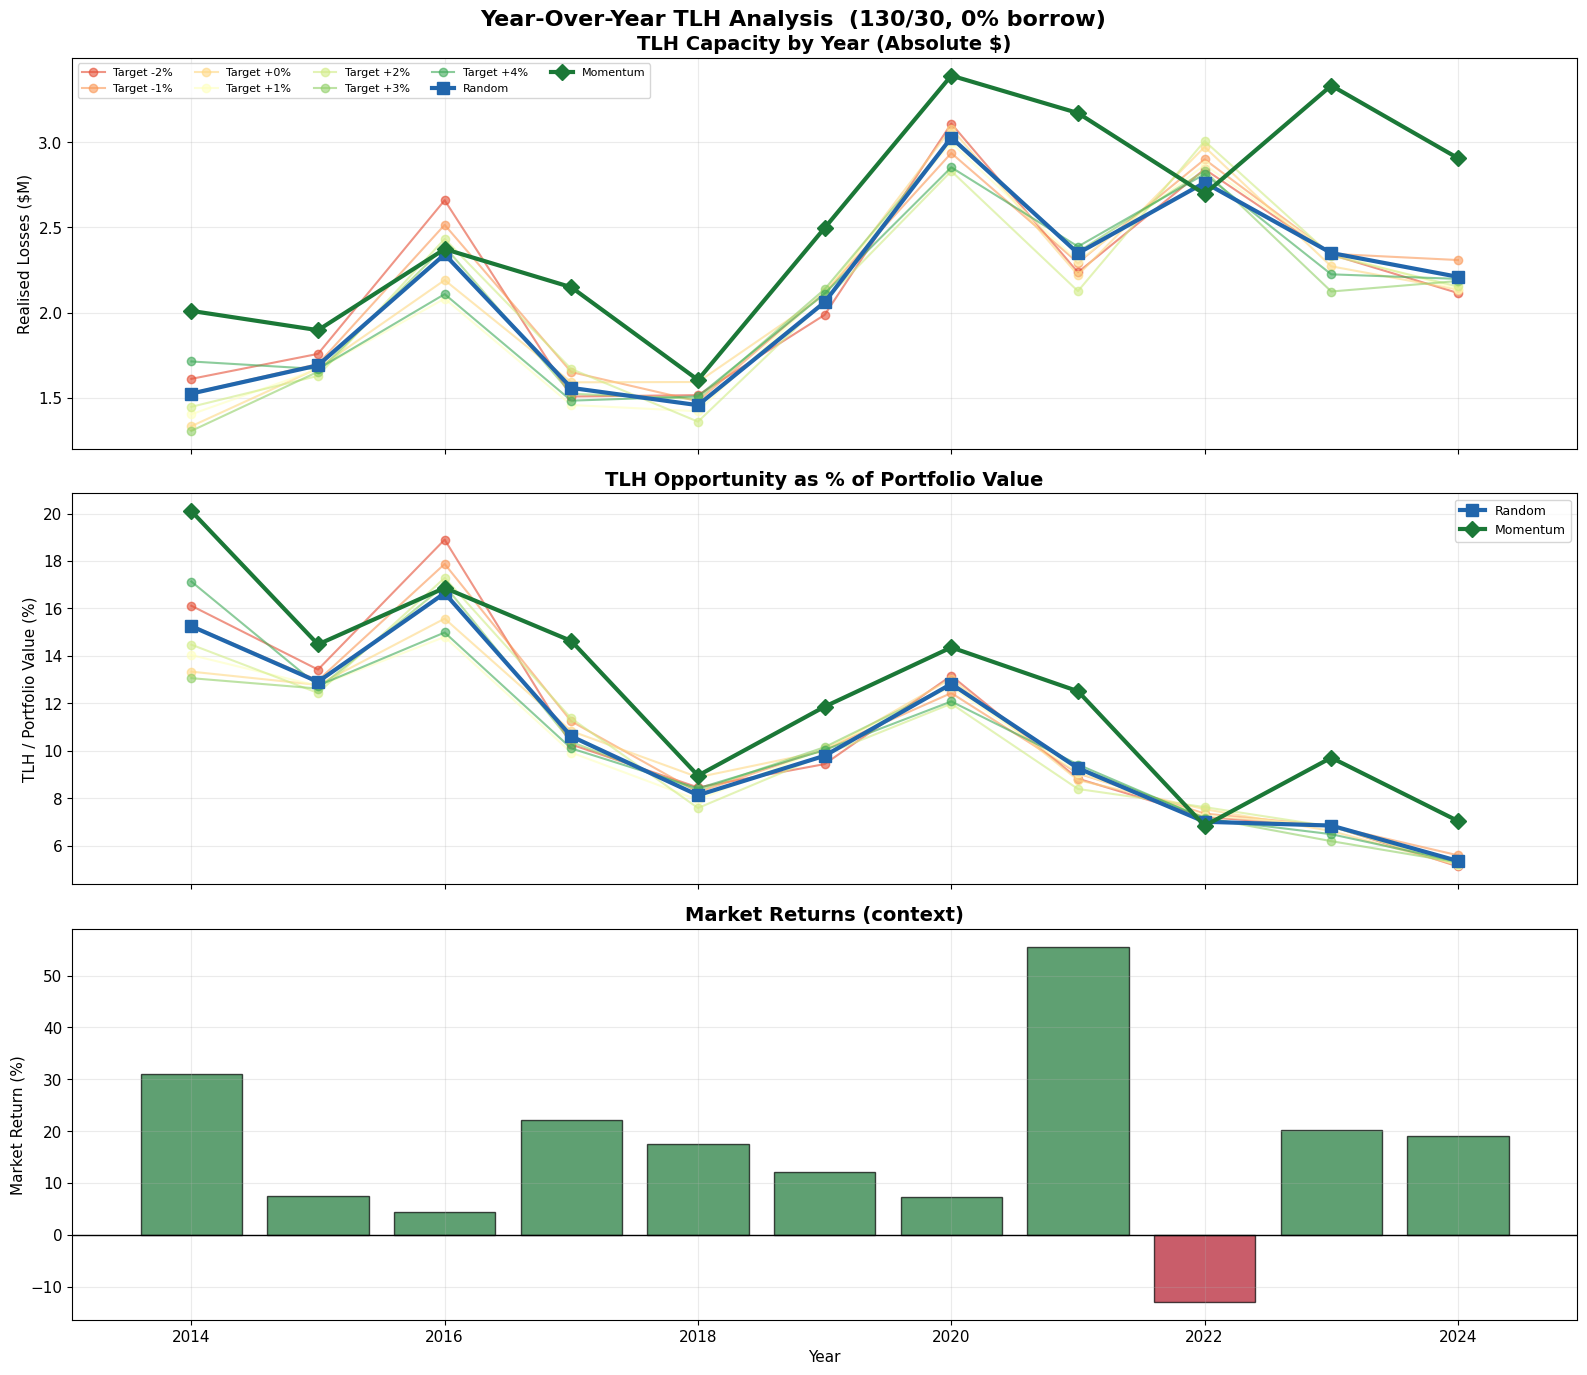

In [30]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

def compute_tlh_pct(df_grouped):
    """Compute TLH as % of estimated portfolio value."""
    rows = []
    port_value = CAPITAL
    
    for year in sorted(df_grouped['year'].unique()):
        year_data = df_grouped[df_grouped['year'] == year]
        avg_rl = year_data['rl'].mean()
        avg_mkt = year_data['mkt'].mean()
        tlh_pct = (avg_rl / port_value) * 100
        rows.append({'year': year, 'tlh_pct': tlh_pct, 'port_value': port_value})
        port_value = port_value * (1 + avg_mkt)
    
    return pd.DataFrame(rows)

yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

rd_pct = compute_tlh_pct(rd)
md_pct = compute_tlh_pct(md)

target_pct_data = []
for t in sorted(TARGET_ALPHAS):
    sub = yd_t[yd_t['target_alpha']==t].copy()
    sub_pct = compute_tlh_pct(sub)
    sub_pct['target_alpha'] = t
    target_pct_data.append(sub_pct)
target_pct = pd.concat(target_pct_data, ignore_index=True)

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: Realised Losses by Year (absolute $) ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['rl']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['rl']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['rl']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('Realised Losses ($M)')
ax1.set_title('TLH Capacity by Year (Absolute $)', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: TLH as % of Portfolio Value ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = target_pct[target_pct['target_alpha']==t]
    ax2.plot(sub['year'], sub['tlh_pct'], 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd_pct['year'], rd_pct['tlh_pct'], 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md_pct['year'], md_pct['tlh_pct'], 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.set_ylabel('TLH / Portfolio Value (%)')
ax2.set_title('TLH Opportunity as % of Portfolio Value', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

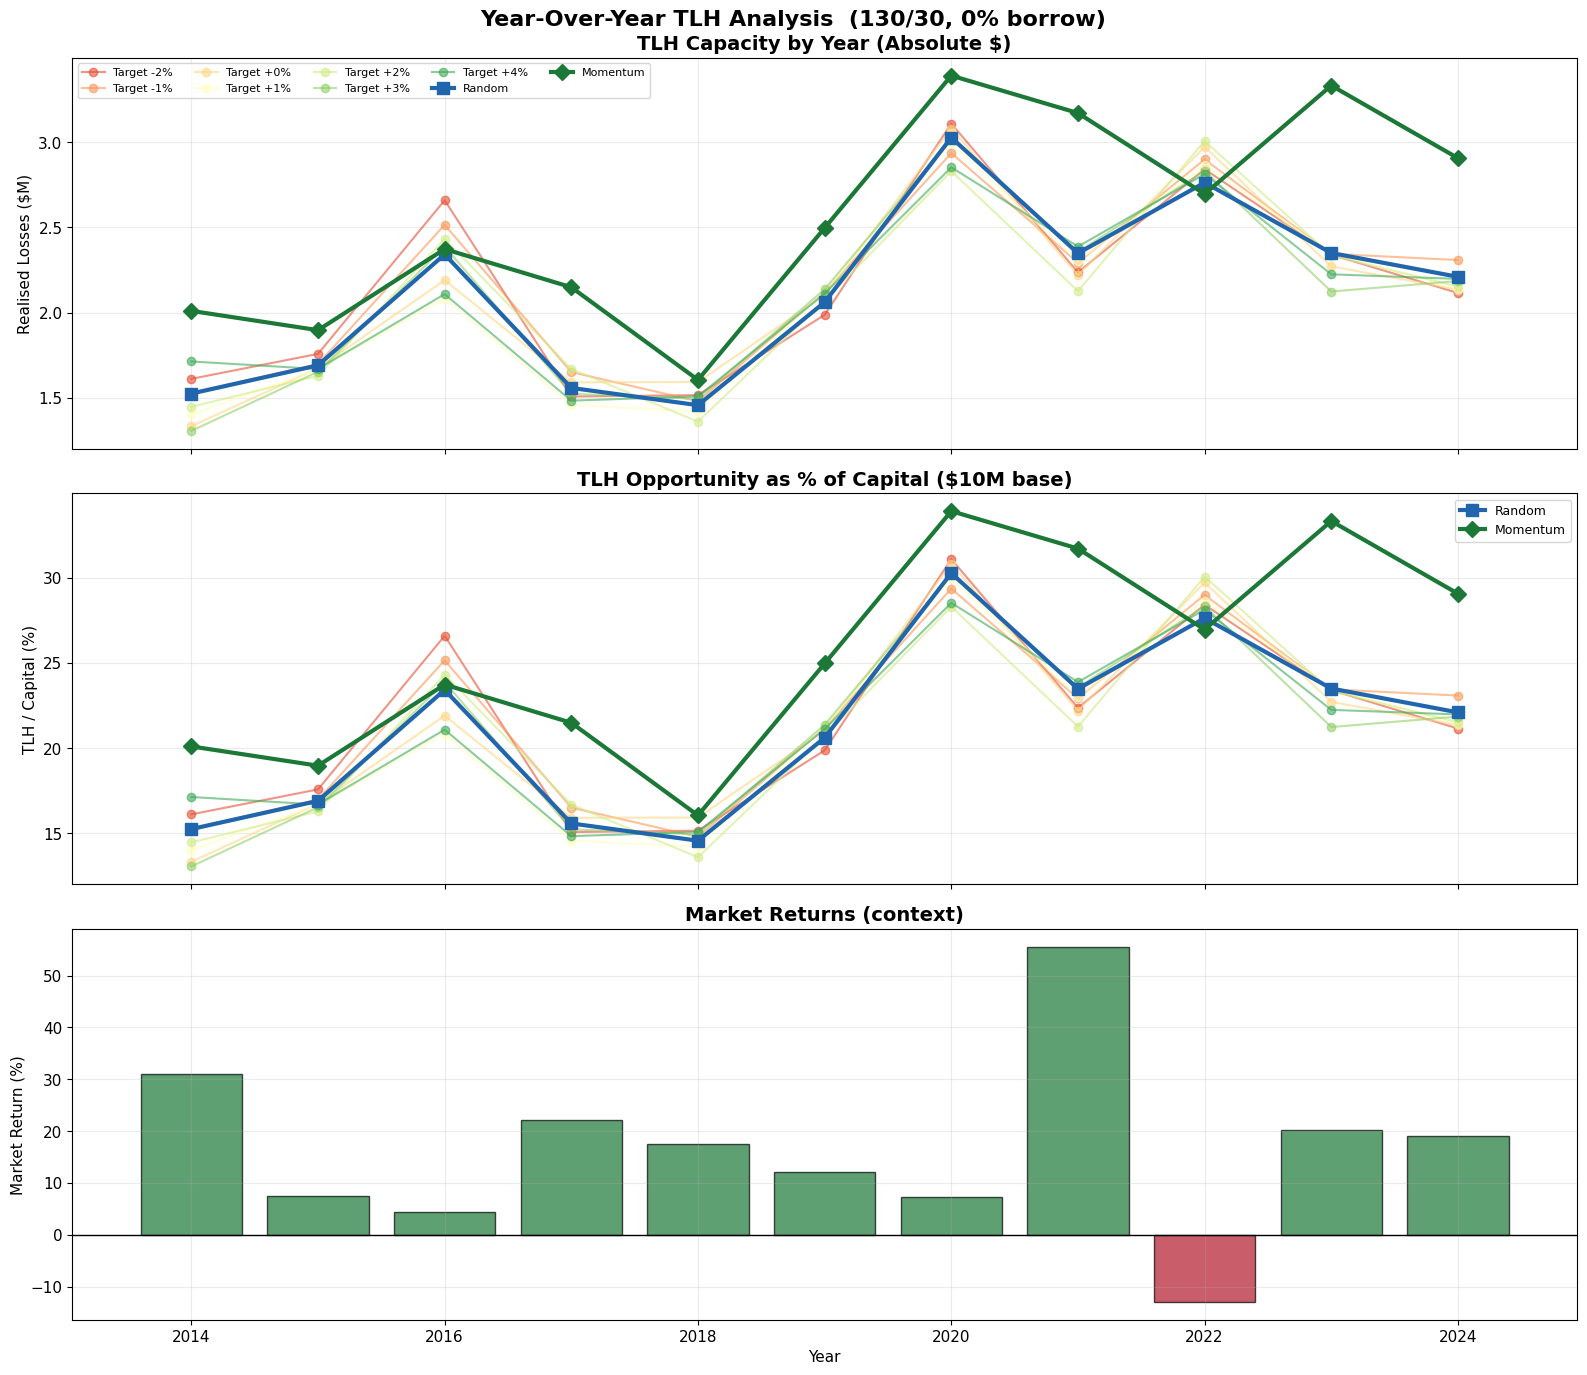

In [31]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), ta=('tax_alpha','mean'), mkt=('market_return','mean')
).reset_index()

# TLH as % of CAPITAL (constant base, comparable across years)
rd['tlh_pct'] = (rd['rl'] / CAPITAL) * 100
md['tlh_pct'] = (md['rl'] / CAPITAL) * 100
yd_t['tlh_pct'] = (yd_t['rl'] / CAPITAL) * 100

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: Realised Losses by Year (absolute $) ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['rl']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['rl']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['rl']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('Realised Losses ($M)')
ax1.set_title('TLH Capacity by Year (Absolute $)', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: TLH as % of Capital ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax2.plot(sub['year'], sub['tlh_pct'], 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd['year'], rd['tlh_pct'], 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md['year'], md['tlh_pct'], 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.set_ylabel('TLH / Capital (%)')
ax2.set_title('TLH Opportunity as % of Capital ($10M base)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

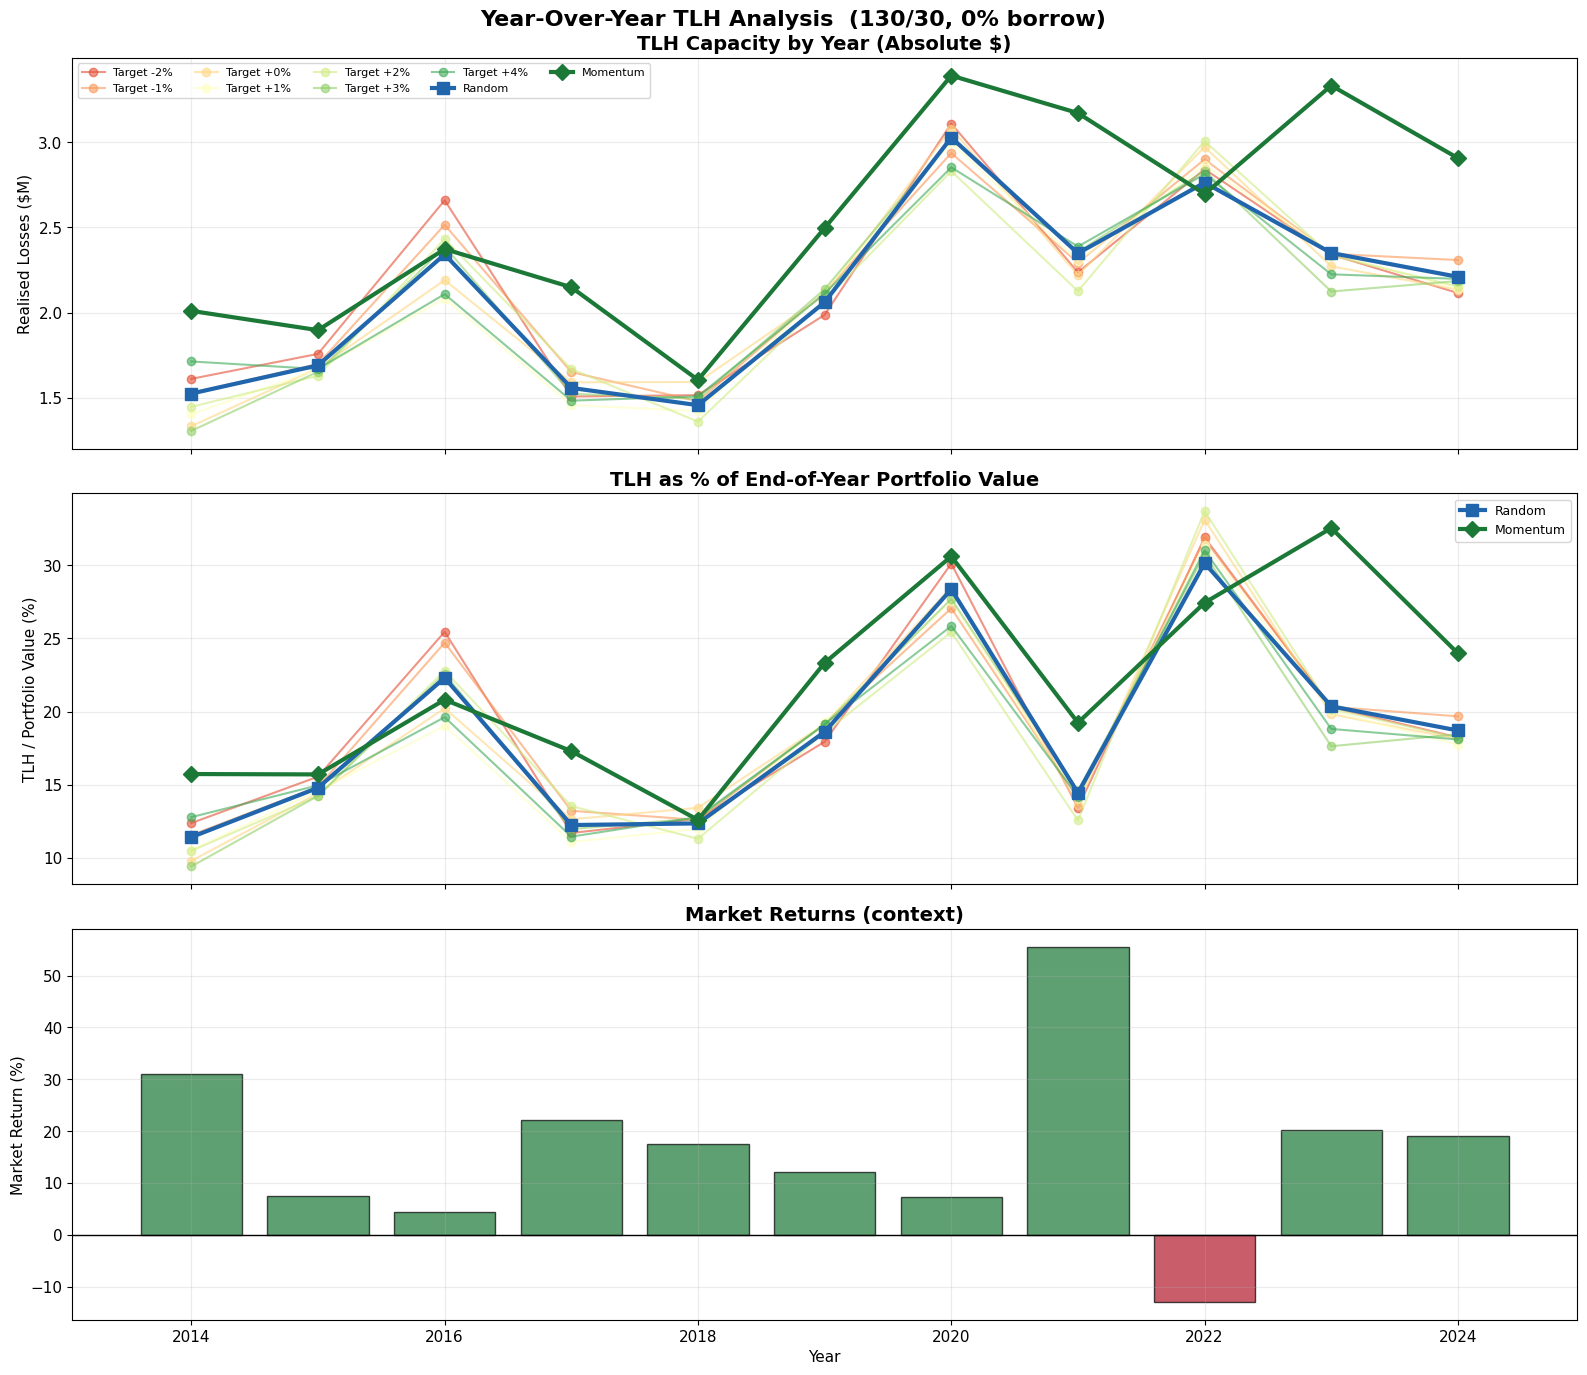

In [32]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

# TLH % = Realized Losses / End-of-Year Portfolio Value
# End-of-year value = CAPITAL * (1 + port_return)
rd['eoy_value'] = CAPITAL * (1 + rd['port_ret'])
md['eoy_value'] = CAPITAL * (1 + md['port_ret'])
yd_t['eoy_value'] = CAPITAL * (1 + yd_t['port_ret'])

rd['tlh_pct'] = (rd['rl'] / rd['eoy_value']) * 100
md['tlh_pct'] = (md['rl'] / md['eoy_value']) * 100
yd_t['tlh_pct'] = (yd_t['rl'] / yd_t['eoy_value']) * 100

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: Realised Losses by Year (absolute $) ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['rl']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['rl']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['rl']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('Realised Losses ($M)')
ax1.set_title('TLH Capacity by Year (Absolute $)', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: TLH as % of End-of-Year Portfolio Value ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax2.plot(sub['year'], sub['tlh_pct'], 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd['year'], rd['tlh_pct'], 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md['year'], md['tlh_pct'], 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.set_ylabel('TLH / Portfolio Value (%)')
ax2.set_title('TLH as % of End-of-Year Portfolio Value', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

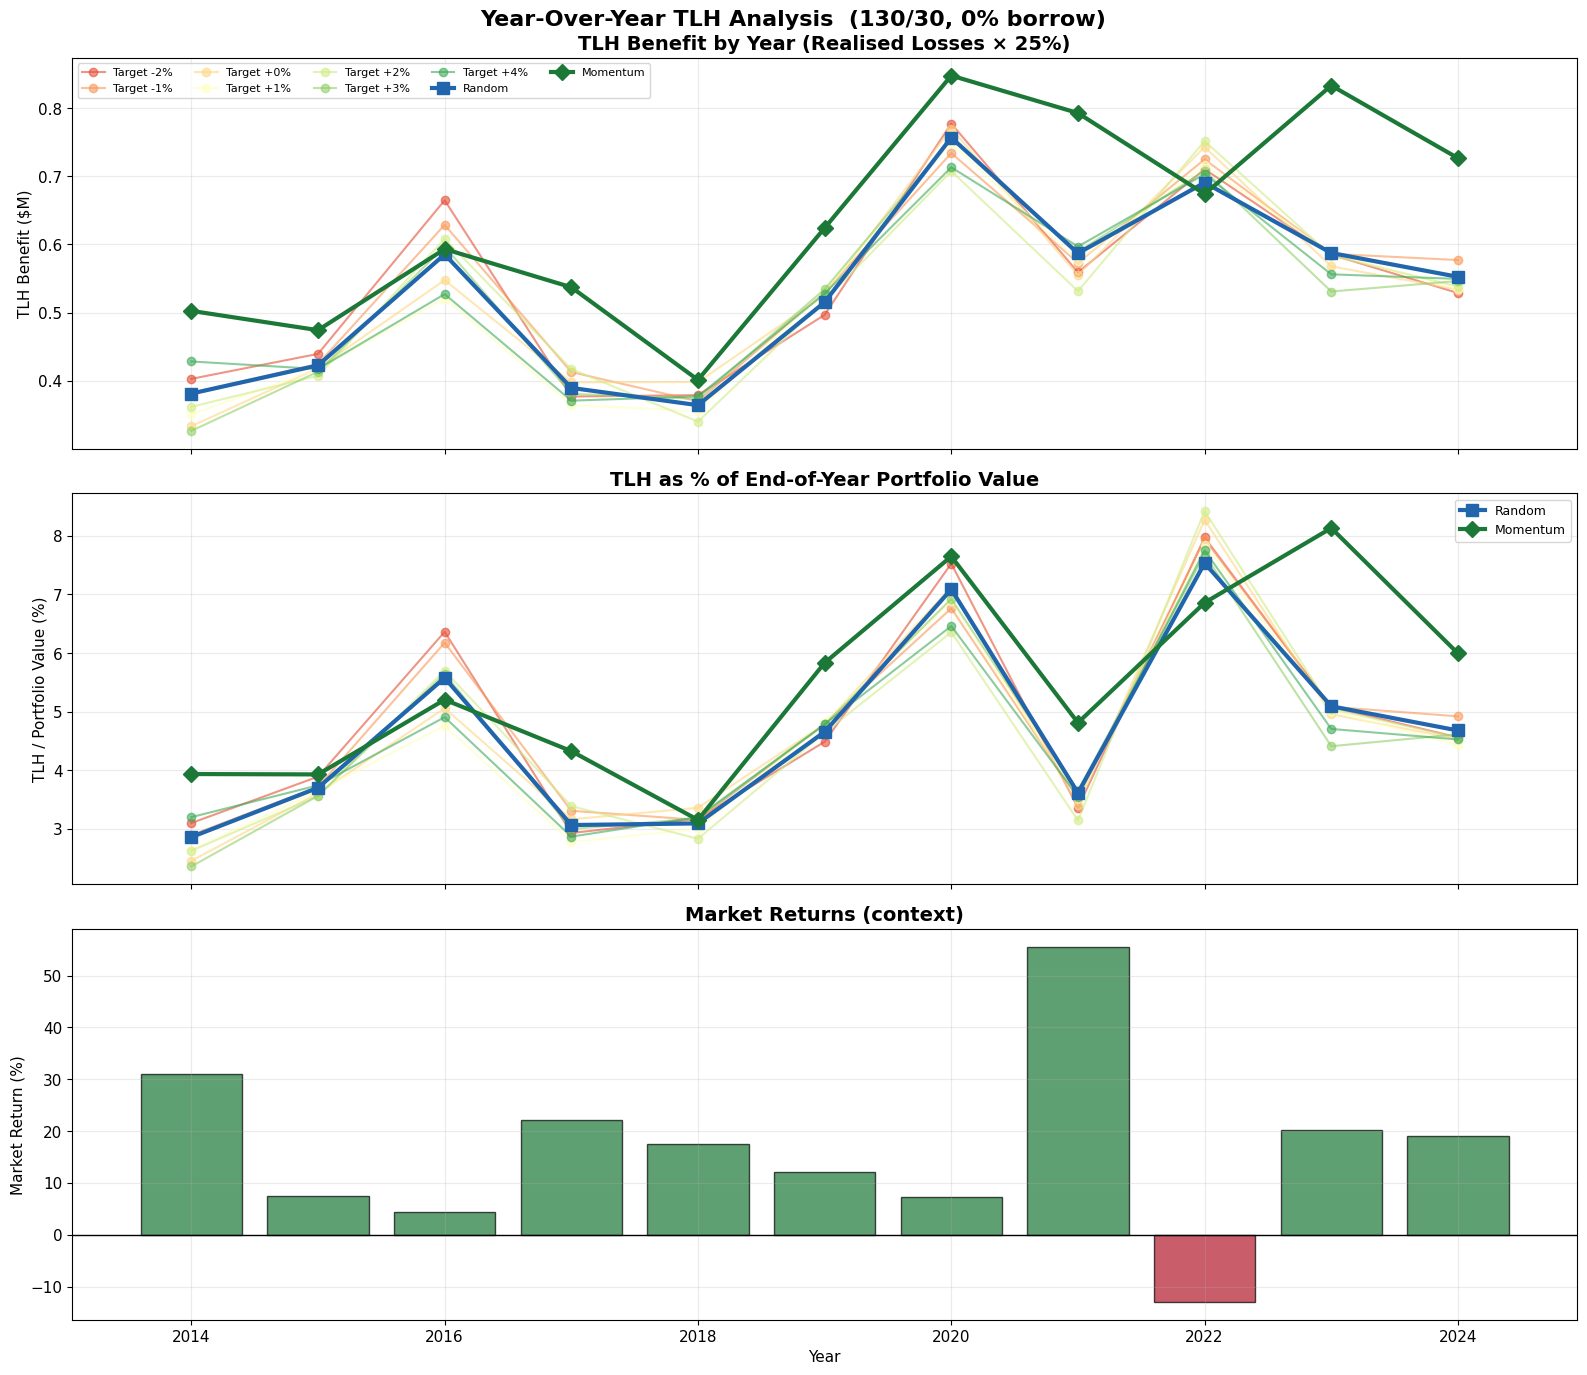

In [33]:
# =============================================================================
# 6f. TIME SERIES: TLH by Year — All Three Strategies
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Year-Over-Year TLH Analysis  (130/30, 0% borrow)', fontsize=16, fontweight='bold')

# --- Prep data ---
ts = df_target[(df_target['leverage_label']=='130/30') & (df_target['borrowing_rate']==0.0)]

yd_t = ts.groupby(['year','target_alpha']).agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

rd = _filt(df_random).groupby('year').agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

md = _filt(df_momentum).groupby('year').agg(
    rl=('realized_losses','mean'), mkt=('market_return','mean'), port_ret=('port_return','mean')
).reset_index()

# TLH = Realized Losses × Tax Rate
rd['tlh'] = rd['rl'] * TAX_RATE
md['tlh'] = md['rl'] * TAX_RATE
yd_t['tlh'] = yd_t['rl'] * TAX_RATE

# TLH % = TLH / End-of-Year Portfolio Value
rd['eoy_value'] = CAPITAL * (1 + rd['port_ret'])
md['eoy_value'] = CAPITAL * (1 + md['port_ret'])
yd_t['eoy_value'] = CAPITAL * (1 + yd_t['port_ret'])

rd['tlh_pct'] = (rd['tlh'] / rd['eoy_value']) * 100
md['tlh_pct'] = (md['tlh'] / md['eoy_value']) * 100
yd_t['tlh_pct'] = (yd_t['tlh'] / yd_t['eoy_value']) * 100

cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(TARGET_ALPHAS)))

# ---- TOP: TLH Benefit by Year (absolute $) ----
ax1 = axes[0]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax1.plot(sub['year'], sub['tlh']/1e6, 'o-', color=cmap[i], lw=1.5, alpha=0.6, label=f'Target {t:+.0%}')

ax1.plot(rd['year'], rd['tlh']/1e6, 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax1.plot(md['year'], md['tlh']/1e6, 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax1.set_ylabel('TLH Benefit ($M)')
ax1.set_title('TLH Benefit by Year (Realised Losses × 25%)', fontsize=14, fontweight='bold')
ax1.legend(ncol=5, fontsize=8, loc='upper left')

# ---- MIDDLE: TLH as % of End-of-Year Portfolio Value ----
ax2 = axes[1]
for i, t in enumerate(sorted(TARGET_ALPHAS)):
    sub = yd_t[yd_t['target_alpha']==t]
    ax2.plot(sub['year'], sub['tlh_pct'], 'o-', color=cmap[i], lw=1.5, alpha=0.6)

ax2.plot(rd['year'], rd['tlh_pct'], 's-', color=COLORS['blue'],  lw=3, markersize=8, label='Random', zorder=5)
ax2.plot(md['year'], md['tlh_pct'], 'D-', color=COLORS['green'], lw=3, markersize=8, label='Momentum', zorder=5)
ax2.set_ylabel('TLH / Portfolio Value (%)')
ax2.set_title('TLH as % of End-of-Year Portfolio Value', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)

# ---- BOTTOM: Market return context ----
ax3 = axes[2]
mkt = yd_t.groupby('year')['mkt'].first()
colors_bar = [COLORS['green'] if v > 0 else COLORS['red'] for v in mkt.values]
ax3.bar(mkt.index, mkt.values*100, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.axhline(0, color='black', lw=1)
ax3.set_ylabel('Market Return (%)')
ax3.set_xlabel('Year')
ax3.set_title('Market Returns (context)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()